# Load Packages

In [ ]:
# ==============================
# Install required packages
# ==============================
!pip install -q --upgrade pip
!pip install -q pyunpack patool rarfile rioxarray rasterio xarray

# ==============================
# Standard library
# ==============================
import os
import sys
import glob
import pathlib
import zipfile

# ==============================
# General utilities
# ==============================
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Image handling
# ==============================
import PIL
from PIL import Image

# ==============================
# Raster / geospatial
# ==============================
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.windows import Window
import rioxarray as rxr

# ==============================
# Archive handling
# ==============================
import pyunpack
from rarfile import RarFile

# ==============================
# TensorFlow / Keras
# ==============================
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, MaxPooling2D,
    UpSampling2D, Dropout, BatchNormalization,
    Activation, concatenate, add, multiply
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# ==============================
# Evaluation metrics
# ==============================
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.5 MB/s eta 0:00:00


In [ ]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Specify whether to download data or read in
download = True
base_dir = "./content/Iraq_Marshes_s2_water_seg/"

In [ ]:
# Download data
if download:
    url = 'https://zenodo.org/records/18601207/files/Iraq_Marshes_s2_water_seg.zip?download=1'

    # download
    r = requests.get(url)
    with open("data.zip", "wb") as f:
      f.write(r.content)

    # extract
    with zipfile.ZipFile("data.zip", "r") as z:
      z.extractall("/content/")

    # confirm
    os.listdir("/content/")

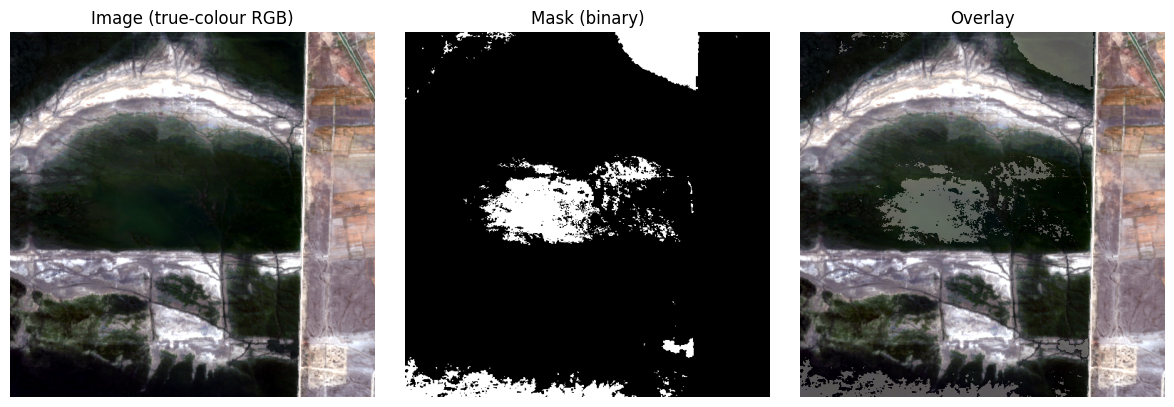

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.10550308227539062


In [ ]:
fname = "central_marshes_2021_r004_c009.npy"
base_dir = "/content/Iraq_Marshes_s2_water_seg/"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir, split, "images", fname)
mask_path = os.path.join(base_dir, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

# Functions

In [ ]:
'''
  Returns an image plot of mask prediction
'''

def reconstruct_image(model, image, rounded=False):

  # Find model prediction
  reconstruction = model.predict(image).reshape(image.shape[1], image.shape[2])
  # Standardise between 0-1
  reconstruction = reconstruction/np.max(reconstruction)

  # Round to 0-1, binary pixel-by-pixel classification
  if rounded:
    reconstruction = np.round(reconstruction)

  # Plot reconstructed mask (prediction)
  plt.imshow(reconstruction)

In [ ]:
'''
  Returns array of mask prediction, given model and image
'''
def reconstruct_array(model, image, rounded=False):

  # Find model prediction
  reconstruction = model.predict(image).reshape(image.shape[1], image.shape[2])

  if rounded:
    reconstruction = np.round(reconstruction)

  return reconstruction # Returns array

In [ ]:
def score_eval2(model, image, mask):
    """Gives score of mask vs prediction"""
    if type(image) != list:
        # Check if we have multiple images
        if image.shape[0] > 1:
            # Evaluate each image separately to get per-image scores
            scores = []
            for i in range(image.shape[0]):
                reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
                reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
                reconstruction = np.round(reconstruction).flatten()
                scores.append(accuracy_score(mask[i].flatten(), reconstruction))
            return scores  # Return list of scores for std calculation
        else:
            # Single image (1, 512, 512, channels)
            reconstruction = model.predict(image, verbose=0)
            reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
            reconstruction = np.round(reconstruction).flatten()
            return accuracy_score(mask.flatten(), reconstruction)
    else:
        # If a list of images input, find accuracy for each
        scores = []
        for i in range(len(image)):
            reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
            reconstruction = np.round(reconstruction).flatten()
            scores.append(accuracy_score(mask[i].flatten(), reconstruction))
        return scores

def score_eval(model, images, masks):
    """
    Evaluate model accuracy on a dataset

    Args:
        model: Trained model
        images: Input images (can be array or list)
        masks: Ground truth masks (can be array or list)

    Returns:
        List of accuracy scores (one per image) if multiple images
        Single accuracy score if one image
    """
    if type(images) != list:
        # Check if we have multiple images
        if images.shape[0] > 1:
            # Evaluate each image separately to get per-image scores
            scores = []
            for i in range(images.shape[0]):
                img = np.expand_dims(images[i], axis=0)
                mask = masks[i]

                reconstruction = model.predict(img, verbose=0)[0]
                reconstruction = reconstruction.reshape(reconstruction.shape[0], reconstruction.shape[1])
                reconstruction = np.round(reconstruction).flatten()

                score = accuracy_score(mask.flatten(), reconstruction)
                scores.append(score)
            return scores
        else:
            # Single image
            reconstruction = model.predict(images, verbose=0)[0]
            reconstruction = reconstruction.reshape(reconstruction.shape[0], reconstruction.shape[1])
            reconstruction = np.round(reconstruction).flatten()
            return accuracy_score(masks.flatten(), reconstruction)
    else:
        # If a list of images input, find accuracy for each
        scores = []
        for i in range(len(images)):
            reconstruction = model.predict(np.expand_dims(images[i], axis=0), verbose=0)
            reconstruction = np.round(reconstruction).flatten()
            scores.append(accuracy_score(masks[i].flatten(), reconstruction))
        return scores



def recall_eval(model, image, mask):
    """Find recall score"""
    if type(image) != list:
        # Check if we have multiple images
        if image.shape[0] > 1:
            # Evaluate each image separately
            recalls = []
            for i in range(image.shape[0]):
                reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
                reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
                reconstruction = np.round(reconstruction).flatten()
                recalls.append(recall_score(mask[i].flatten(), reconstruction, average='weighted', zero_division=0))
            return recalls  # Return list for std calculation
        else:
            # Single image
            reconstruction = model.predict(image, verbose=0)
            reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
            reconstruction = np.round(reconstruction).flatten()
            return recall_score(mask.flatten(), reconstruction, average='weighted', zero_division=0)
    else:
        # If a list of images input, find recall for each
        recalls = []
        for i in range(len(image)):
            reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
            reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
            reconstruction = np.round(reconstruction).flatten()
            recalls.append(recall_score(mask[i].flatten(), reconstruction, average='weighted', zero_division=0))
        return recalls


def precision_eval(model, image, mask):
    """Find precision score"""
    if type(image) != list:
        # Check if we have multiple images
        if image.shape[0] > 1:
            # Evaluate each image separately
            precisions = []
            for i in range(image.shape[0]):
                reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
                reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
                reconstruction = np.round(reconstruction).flatten()
                precisions.append(precision_score(mask[i].flatten(), reconstruction, average='weighted', zero_division=0))
            return precisions  # Return list for std calculation
        else:
            # Single image
            reconstruction = model.predict(image, verbose=0)
            reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
            reconstruction = np.round(reconstruction).flatten()
            return precision_score(mask.flatten(), reconstruction, average='weighted', zero_division=0)
    else:
        # If a list of images input, find precision for each
        precisions = []
        for i in range(len(image)):
            reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
            reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
            reconstruction = np.round(reconstruction).flatten()
            precisions.append(precision_score(mask[i].flatten(), reconstruction, average='weighted', zero_division=0))
        return precisions


def f1_score_eval_basic(precision, recall):
    """Calculate F1-score from precision and recall"""

    if isinstance(precision, (list, np.ndarray)):
        prec = np.mean(precision)
    else:
        prec = precision

    if isinstance(recall, (list, np.ndarray)):
        rec = np.mean(recall)
    else:
        rec = recall

    if prec + rec == 0:
        return 0.0

    return 2 * (prec * rec) / (prec + rec)


# Ingest and Process RGB Dataset

In [ ]:

# ==============================================================================
# INGEST IMAGES
# ==============================================================================

## Training images
training_images_list = os.listdir(f"{base_dir}training/images/")
training_masks_list = []
training_images = []

for n in training_images_list:
    a = np.load(f"{base_dir}training/images/{n}")

    # Extract only RGB channels (first 3 bands)
    if a.ndim == 3 and a.shape[-1] > 3:
        a = a[:, :, :3]

    training_images.append(a)
    training_masks_list.append(n)  # Same filename for mask

## Training masks
training_masks = []
for n in training_masks_list:
    a = np.load(f"{base_dir}training/masks/{n}")
    training_masks.append(a)

## Test images
test_images_list = os.listdir(f"{base_dir}test/images/")
test_images = []
for n in test_images_list:
    a = np.load(f"{base_dir}test/images/{n}")

    # Extract only RGB channels (first 3 bands)
    if a.ndim == 3 and a.shape[-1] > 3:
        a = a[:, :, :3]

    test_images.append(a)

## Test masks
test_masks_list = []
test_masks = []
for n in test_images_list:
    test_masks_list.append(n)

for n in test_masks_list:
    a = np.load(f"{base_dir}test/masks/{n}")
    test_masks.append(a)

## Validation images
validation_images_list = os.listdir(f"{base_dir}validation/images/")
validation_masks_list = []
validation_images = []

for n in validation_images_list:
    a = np.load(f"{base_dir}validation/images/{n}")

    # Extract only RGB channels (first 3 bands)
    if a.ndim == 3 and a.shape[-1] > 3:
        a = a[:, :, :3]

    validation_images.append(a)
    validation_masks_list.append(n)  # Same filename for mask

## Validation masks
validation_masks = []
for n in validation_masks_list:
    a = np.load(f"{base_dir}validation/masks/{n}")
    validation_masks.append(a)

print(f"Loaded:")
print(f"Training: {len(training_images)} images, {len(training_masks)} masks")
print(f"Validation: {len(validation_images)} images, {len(validation_masks)} masks")
print(f"Test: {len(test_images)} images, {len(test_masks)} masks")
print(f"\nShapes:")
print(f"Training image: {training_images[0].shape}")
print(f"Training mask: {training_masks[0].shape}")

Loaded:
Training: 143 images, 143 masks
Validation: 99 images, 99 masks
Test: 20 images, 20 masks

Shapes:
Training image: (512, 512, 3)
Training mask: (512, 512, 1)



Preprocessing training data...


/tmp/ipython-input-1899423445.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr_uint8, mode="RGB")


Preprocessing validation data...
Preprocessing test data...

PREPROCESSED ARRAYS:
X_train: (143, 512, 512, 3) float32 range: [0.000, 1.000]
Y_train: (143, 512, 512, 1) uint8 unique: [0 1]
X_val  : (99, 512, 512, 3) float32 range: [0.000, 1.000]
Y_val  : (99, 512, 512, 1) uint8 unique: [0 1]
X_test : (20, 512, 512, 3) float32 range: [0.000, 1.000]
Y_test : (20, 512, 512, 1) uint8 unique: [0 1]


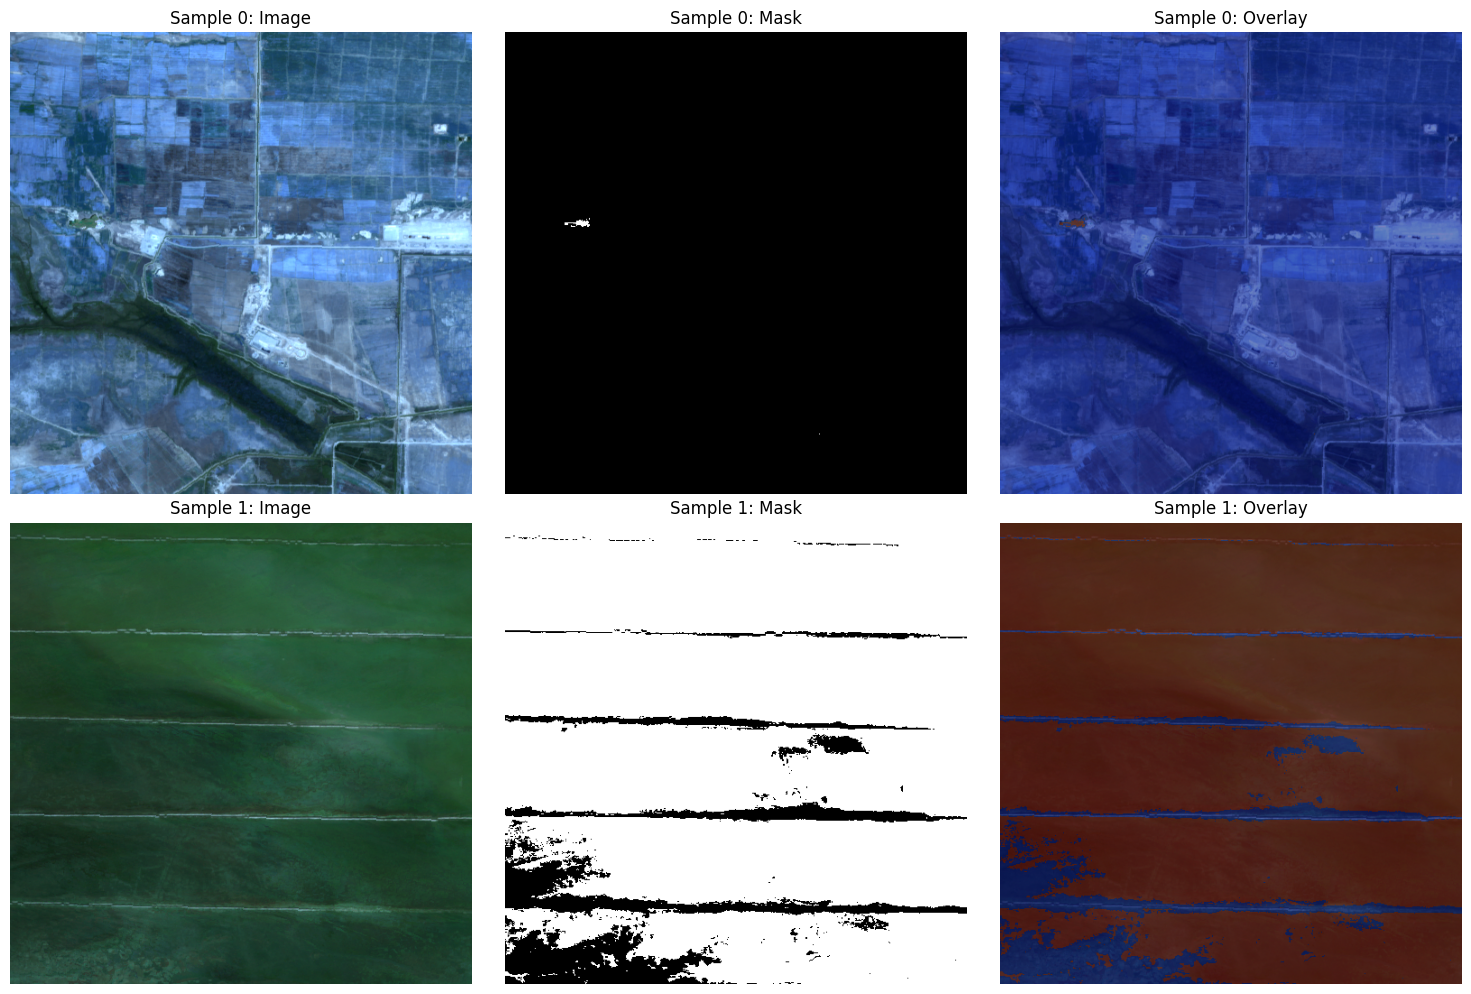


Mask value check:
Unique values in mask: [0 1]
Percentage of water (value=1): 0.04%
Percentage of non-water (value=0): 99.96%


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

IMG_SIZE = 512

def preprocess_img_npy(img_array, size=IMG_SIZE):
    """Preprocess numpy array image to RGB float32."""
    arr = img_array.copy()

    # Already RGB from loading step, but verify
    if arr.ndim == 3 and arr.shape[-1] > 3:
        arr = arr[..., :3]

    # Determine value range and normalize
    if arr.max() > 1.0:
        # Assume 0-255 or 0-10000 range
        arr = arr.astype(np.float32) / arr.max()
    else:
        # Already in 0-1 range
        arr = arr.astype(np.float32)

    # Convert to uint8 for PIL
    arr_uint8 = (arr * 255.0).clip(0, 255).astype(np.uint8)

    # Resize using PIL
    img = Image.fromarray(arr_uint8, mode="RGB")
    img = img.resize((size, size), resample=Image.BILINEAR)

    # Convert back to float32 [0, 1]
    return np.asarray(img, dtype=np.float32) / 255.0

def preprocess_mask_npy(mask_array, size=IMG_SIZE):
    """Preprocess numpy array mask to binary uint8."""
    y = mask_array.copy()

    # Handle multi-dimensional masks
    if y.ndim == 3:
        y = y[..., 0]  # Take first channel

    # Binarize
    y = (y > 0).astype(np.uint8)

    # Resize if needed
    if y.shape[0] != size or y.shape[1] != size:
        y_img = Image.fromarray(y)
        y_img = y_img.resize((size, size), resample=Image.NEAREST)
        y = np.asarray(y_img, dtype=np.uint8)

    return y  # Return (512, 512) - NO extra dimension yet

# Apply preprocessing
print("\nPreprocessing training data...")
training_images_processed = [preprocess_img_npy(im) for im in training_images]
training_masks_processed = [preprocess_mask_npy(m) for m in training_masks]

print("Preprocessing validation data...")
validation_images_processed = [preprocess_img_npy(im) for im in validation_images]
validation_masks_processed = [preprocess_mask_npy(m) for m in validation_masks]

print("Preprocessing test data...")
test_images_processed = [preprocess_img_npy(im) for im in test_images]
test_masks_processed = [preprocess_mask_npy(m) for m in test_masks]

# Stack into simple arrays (no transpose, no reshape)
X_train = np.array(training_images_processed, dtype=np.float32)  # (N, 512, 512, 3)
Y_train = np.array(training_masks_processed, dtype=np.uint8)     # (N, 512, 512)
Y_train = Y_train[..., np.newaxis]  # Add channel: (N, 512, 512, 1)

X_val = np.array(validation_images_processed, dtype=np.float32)
Y_val = np.array(validation_masks_processed, dtype=np.uint8)
Y_val = Y_val[..., np.newaxis]

X_test = np.array(test_images_processed, dtype=np.float32)
Y_test = np.array(test_masks_processed, dtype=np.uint8)
Y_test = Y_test[..., np.newaxis]

# ==============================================================================
# DISPLAY RESULTS
# ==============================================================================

print("\n" + "="*60)
print("PREPROCESSED ARRAYS:")
print("="*60)
print(f"X_train: {X_train.shape} {X_train.dtype} range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Y_train: {Y_train.shape} {Y_train.dtype} unique: {np.unique(Y_train)}")
print(f"X_val  : {X_val.shape} {X_val.dtype} range: [{X_val.min():.3f}, {X_val.max():.3f}]")
print(f"Y_val  : {Y_val.shape} {Y_val.dtype} unique: {np.unique(Y_val)}")
print(f"X_test : {X_test.shape} {X_test.dtype} range: [{X_test.min():.3f}, {X_test.max():.3f}]")
print(f"Y_test : {Y_test.shape} {Y_test.dtype} unique: {np.unique(Y_test)}")
print("="*60)

# Visualize samples
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i in range(2):
    idx = i

    # Now shapes are clean: X_train[idx] is (512, 512, 3), Y_train[idx] is (512, 512, 1)
    img_display = X_train[idx]
    mask_display = Y_train[idx, :, :, 0]

    # Original image
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f'Sample {idx}: Image')
    axes[i, 0].axis('off')

    # Mask
    axes[i, 1].imshow(mask_display, cmap='gray')
    axes[i, 1].set_title(f'Sample {idx}: Mask')
    axes[i, 1].axis('off')

    # Overlay
    axes[i, 2].imshow(img_display)
    axes[i, 2].imshow(mask_display, cmap='jet', alpha=0.5)
    axes[i, 2].set_title(f'Sample {idx}: Overlay')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Check mask values
print("\nMask value check:")
sample_mask = Y_train[0, :, :, 0]
print(f"Unique values in mask: {np.unique(sample_mask)}")
print(f"Percentage of water (value=1): {100 * np.sum(sample_mask == 1) / sample_mask.size:.2f}%")
print(f"Percentage of non-water (value=0): {100 * np.sum(sample_mask == 0) / sample_mask.size:.2f}%")

In [ ]:
print("Train image:", np.array(training_images[0]).shape)
print("Train mask :", np.array(training_masks[0]).shape, np.unique(training_masks[0])[:10])


Train image: (512, 512, 3)
Train mask : (512, 512, 1) [0 1]


In [ ]:
# Create TensorFlow dataset from validation arrays
validation_df = tf.data.Dataset.from_tensor_slices((X_val, Y_val))
validation_df = validation_df.batch(1)  # ← CRITICAL: Add batching to match training


In [ ]:

def adjustData(img, mask, num_class):
    mask[mask > 0.5] = 1  # WATER
    mask[mask <= 0.5] = 0  # NON-WATER
    return (img, mask)

def trainGenerator(batch_size,
                   image_array,
                   mask_array,
                   aug_dict,
                   image_save_prefix="image",
                   mask_save_prefix="mask",
                   num_class=2,
                   save_to_dir=None,
                   target_size=(512, 512),
                   seed=1):

    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)

    image_generator = image_datagen.flow(image_array,
                                         batch_size=batch_size,
                                         save_to_dir=save_to_dir,
                                         save_prefix=image_save_prefix,
                                         seed=seed)

    mask_generator = mask_datagen.flow(mask_array,
                                       batch_size=batch_size,
                                       save_to_dir=save_to_dir,
                                       save_prefix=mask_save_prefix,
                                       seed=seed)

    train_generator = zip(image_generator, mask_generator)

    for (img, mask) in train_generator:
        img, mask = adjustData(img, mask, num_class)
        yield (img, mask)


In [ ]:

# ==============================================================================
# DATA AUGMENTATION PARAMETERS
# ==============================================================================

# Training augmentation (with transformations)
data_gen_args = dict(rotation_range=180,
                     width_shift_range=0.25,
                     height_shift_range=0.25,
                     shear_range=0.25,
                     zoom_range=0.25,
                     horizontal_flip=True,
                     vertical_flip=True,
                     fill_mode='reflect')

# Validation augmentation (NO transformations)
validation_gen_args = dict()

# ==============================================================================
# CREATE GENERATORS - Use your preprocessed arrays directly
# ==============================================================================

# Training generator with augmentation
train = trainGenerator(1, X_train, Y_train, data_gen_args, save_to_dir=None)

# Validation generator without augmentation
validation_gen = trainGenerator(1, X_val, Y_val, validation_gen_args, save_to_dir=None)

# Ingest and Process 4-band Datasets

## 4-band Marshes dataset

In [ ]:
base_dir2 = r"./content/Iraq_Marshes_s2_water_seg/"

In [ ]:
base_dir2 = "/content/Iraq_Marshes_s2_water_seg/"

# Ingest images and normalize
def minmax_norm(a, eps=1e-8):
    """Per-image min-max normalization to [0, 1]."""
    a = a.astype(np.float32)
    amin = np.min(a)
    amax = np.max(a)
    return (a - amin) / (amax - amin + eps)

def ensure_mask_hw1(m):
    """Ensure mask is (H, W, 1) shape."""
    m = np.array(m)
    # squeeze common odd shapes
    if m.ndim == 3 and m.shape[-1] == 1:
        return m.astype(np.int32)
    if m.ndim == 3 and m.shape[0] == 1:
        m = m[0]
    if m.ndim == 2:
        m = m[..., None]
    return m.astype(np.int32)

def only_npy(files):
    """Filter for .npy files only."""
    return [f for f in files if f.lower().endswith(".npy")]

# =========================
# TRAIN (4-band)
# =========================
train_img_dir2  = os.path.join(base_dir2, "training", "images")
train_mask_dir2 = os.path.join(base_dir2, "training", "masks")

training_images_list2 = only_npy(os.listdir(train_img_dir2))[:250]
training_masks_list2 = []
training_images2 = []

for n in training_images_list2:
    training_masks_list2.append(n)  # Same filename for mask

    # Load image (H, W, 4) - rasterio format is (bands, H, W), np.load is (H, W, bands)
    a = np.load(os.path.join(train_img_dir2, n))
    a = minmax_norm(a)  # Normalize to [0, 1]
    training_images2.append(a)

## Training masks
training_masks2 = []
for n in training_masks_list2:
    a = np.load(os.path.join(train_mask_dir2, n))
    training_masks2.append(ensure_mask_hw1(a))

# =========================
# TEST (4-band)
# =========================
test_img_dir2  = os.path.join(base_dir2, "test", "images")
test_mask_dir2 = os.path.join(base_dir2, "test", "masks")

test_images_list2 = only_npy(os.listdir(test_img_dir2))
test_masks_list2 = []
test_images2 = []

for n in test_images_list2:
    test_masks_list2.append(n)

    a = np.load(os.path.join(test_img_dir2, n))
    a = minmax_norm(a)
    test_images2.append(a)

## Test masks
test_masks2 = []
for n in test_masks_list2:
    a = np.load(os.path.join(test_mask_dir2, n))
    test_masks2.append(ensure_mask_hw1(a))

# =========================
# VALIDATION (4-band)
# =========================
val_img_dir2  = os.path.join(base_dir2, "validation", "images")
val_mask_dir2 = os.path.join(base_dir2, "validation", "masks")

validation_images_list2 = only_npy(os.listdir(val_img_dir2))
validation_masks_list2 = []
validation_images2 = []

for n in validation_images_list2:
    validation_masks_list2.append(n)

    a = np.load(os.path.join(val_img_dir2, n))
    a = minmax_norm(a)
    validation_images2.append(a)

## Validation masks
validation_masks2 = []
for n in validation_masks_list2:
    a = np.load(os.path.join(val_mask_dir2, n))
    validation_masks2.append(ensure_mask_hw1(a))

# =========================
# Verify
# =========================
print("Loaded:")
print(f"Training: {len(training_images2)} images, {len(training_masks2)} masks")
print(f"Validation: {len(validation_images2)} images, {len(validation_masks2)} masks")
print(f"Test: {len(test_images2)} images, {len(test_masks2)} masks")

print(f"\nShapes:")
print(f"Training image: {training_images2[0].shape} dtype: {training_images2[0].dtype}")
print(f"Training mask: {training_masks2[0].shape} dtype: {training_masks2[0].dtype}")

print(f"\nValue ranges:")
print(f"Image range: [{training_images2[0].min():.3f}, {training_images2[0].max():.3f}]")
print(f"Mask unique: {np.unique(training_masks2[0])}")

Loaded:
Training: 143 images, 143 masks
Validation: 99 images, 99 masks
Test: 20 images, 20 masks

Shapes:
Training image: (512, 512, 4) dtype: float32
Training mask: (512, 512, 1) dtype: int32

Value ranges:
Image range: [0.000, 1.000]
Mask unique: [0 1]


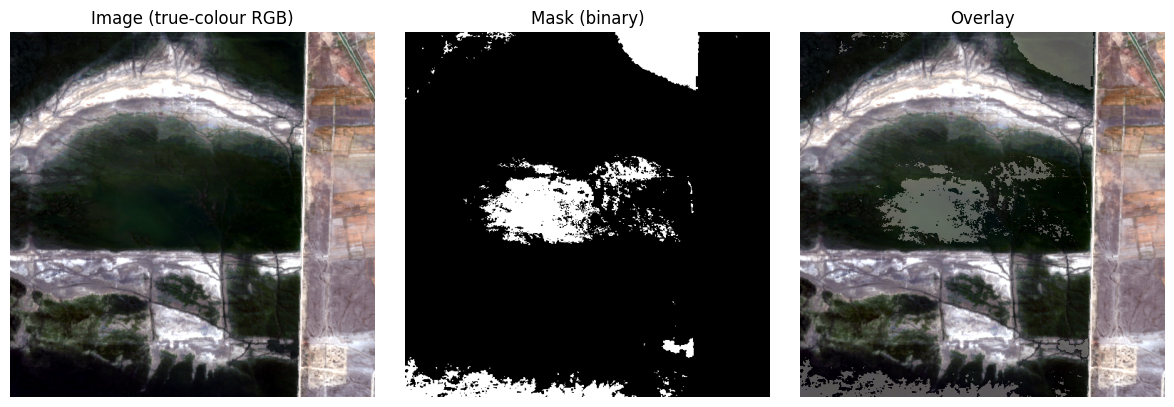

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.10550308227539062


In [ ]:
fname = "central_marshes_2021_r004_c009.npy"
base_dir = "/content/Iraq_Marshes_s2_water_seg"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir, split, "images", fname)
mask_path = os.path.join(base_dir, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

In [ ]:
# =========================
# PRE-PROCESS DATA: NO TRANSPOSE
# =========================

# Images: just ensure float32, no transpose
for i in range(len(training_images2)):
    training_images2[i] = training_images2[i].astype('float32')

for i in range(len(validation_images2)):
    validation_images2[i] = validation_images2[i].astype('float32')

for i in range(len(test_images2)):
    test_images2[i] = test_images2[i].astype('float32')

# Masks: ensure correct shape (512, 512, 1), no transpose
for i in range(len(training_masks2)):
    if training_masks2[i].ndim == 2:
        training_masks2[i] = training_masks2[i][..., np.newaxis]

for i in range(len(validation_masks2)):
    if validation_masks2[i].ndim == 2:
        validation_masks2[i] = validation_masks2[i][..., np.newaxis]

for i in range(len(test_masks2)):
    if test_masks2[i].ndim == 2:
        test_masks2[i] = test_masks2[i][..., np.newaxis]

# Convert to numpy arrays
training_images2 = np.array(training_images2, dtype=np.float32)
training_masks2 = np.array(training_masks2, dtype=np.uint8)

validation_images2 = np.array(validation_images2, dtype=np.float32)
validation_masks2 = np.array(validation_masks2, dtype=np.uint8)

test_images2 = np.array(test_images2, dtype=np.float32)
test_masks2 = np.array(test_masks2, dtype=np.uint8)

# =========================
# VERIFY FINAL SHAPES
# =========================

print("\n" + "="*60)
print("AFTER PREPROCESSING:")
print("="*60)
print(f"Training images shape: {training_images2.shape}")  # Should be (N, 512, 512, 4)
print(f"Training masks shape: {training_masks2.shape}")    # Should be (N, 512, 512, 1)
print(f"Validation images shape: {validation_images2.shape}")
print(f"Validation masks shape: {validation_masks2.shape}")
print(f"Test images shape: {test_images2.shape}")
print(f"Test masks shape: {test_masks2.shape}")
print("="*60)


AFTER PREPROCESSING:
Training images shape: (143, 512, 512, 4)
Training masks shape: (143, 512, 512, 1)
Validation images shape: (99, 512, 512, 4)
Validation masks shape: (99, 512, 512, 1)
Test images shape: (20, 512, 512, 4)
Test masks shape: (20, 512, 512, 1)


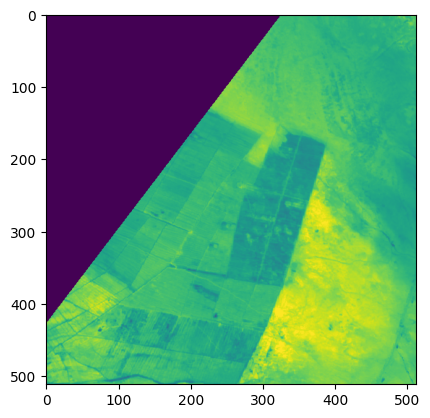

In [ ]:
# Plot example training image first band
plt.imshow(training_images2[2].reshape(512,512,4)[:,:,0])

In [ ]:
# Create TensorFlow datasets for training and validation sets
train_df_4band_marshes = tf.data.Dataset.from_tensor_slices((training_images2[0:250], training_masks2[0:250]))
train_df_4band_marshes = train_df_4band_marshes.batch(1)

validation_df_4band_marshes = tf.data.Dataset.from_tensor_slices((validation_images2, validation_masks2))
validation_df_4band_marshes = validation_df_4band_marshes.batch(1)

## 4-band Lake dataset

In [ ]:
# Specify whether to download data or read in
download = True
base_dir3 = "/content/Iraq_Lake_s2_water_seg/"

In [ ]:
# Download data (Atlantic Forest)
if download:
    # Download data
    url = "https://zenodo.org/records/18601352/files/Iraq_Lake_s2_water_seg.zip?download=1"

    # download
    r = requests.get(url)
    with open("data.zip", "wb") as f:
        f.write(r.content)

    # extract
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall("/content/")

    # confirm
    os.listdir("/content/")


In [ ]:
# Ingest images and normalize
def minmax_norm(a, eps=1e-8):
    """Per-image min-max normalization to [0, 1]."""
    a = a.astype(np.float32)
    amin = np.min(a)
    amax = np.max(a)
    return (a - amin) / (amax - amin + eps)

def ensure_mask_hw1(m):
    """Ensure mask is (H, W, 1) shape."""
    m = np.array(m)
    # squeeze common odd shapes
    if m.ndim == 3 and m.shape[-1] == 1:
        return m.astype(np.int32)
    if m.ndim == 3 and m.shape[0] == 1:
        m = m[0]
    if m.ndim == 2:
        m = m[..., None]
    return m.astype(np.int32)

def only_npy(files):
    """Filter for .npy files only."""
    return [f for f in files if f.lower().endswith(".npy")]

# =========================
# TRAIN (4-band)
# =========================
train_img_dir3  = os.path.join(base_dir3, "training", "images")
train_mask_dir3 = os.path.join(base_dir3, "training", "masks")

training_images_list3 = only_npy(os.listdir(train_img_dir3))[:250]
training_masks_list3 = []
training_images3 = []

for n in training_images_list3:
    training_masks_list3.append(n)  # Same filename for mask

    # Load image (H, W, 4) - rasterio format is (bands, H, W), np.load is (H, W, bands)
    a = np.load(os.path.join(train_img_dir3, n))
    a = minmax_norm(a)  # Normalize to [0, 1]
    training_images3.append(a)

## Training masks
training_masks3 = []
for n in training_masks_list3:
    a = np.load(os.path.join(train_mask_dir3, n))
    training_masks3.append(ensure_mask_hw1(a))

# =========================
# TEST (4-band)
# =========================
test_img_dir3  = os.path.join(base_dir3, "test", "images")
test_mask_dir3 = os.path.join(base_dir3, "test", "masks")

test_images_list3 = only_npy(os.listdir(test_img_dir3))
test_masks_list3 = []
test_images3 = []

for n in test_images_list3:
    test_masks_list3.append(n)

    a = np.load(os.path.join(test_img_dir3, n))
    a = minmax_norm(a)
    test_images3.append(a)

## Test masks
test_masks3 = []
for n in test_masks_list3:
    a = np.load(os.path.join(test_mask_dir3, n))
    test_masks3.append(ensure_mask_hw1(a))

# =========================
# VALIDATION (4-band)
# =========================
val_img_dir3  = os.path.join(base_dir3, "validation", "images")
val_mask_dir3 = os.path.join(base_dir3, "validation", "masks")

validation_images_list3 = only_npy(os.listdir(val_img_dir3))
validation_masks_list3 = []
validation_images3 = []

for n in validation_images_list3:
    validation_masks_list3.append(n)

    a = np.load(os.path.join(val_img_dir3, n))
    a = minmax_norm(a)
    validation_images3.append(a)

## Validation masks
validation_masks3 = []
for n in validation_masks_list3:
    a = np.load(os.path.join(val_mask_dir3, n))
    validation_masks3.append(ensure_mask_hw1(a))

# =========================
# Verify
# =========================
print("Loaded:")
print(f"Training: {len(training_images3)} images, {len(training_masks3)} masks")
print(f"Validation: {len(validation_images3)} images, {len(validation_masks3)} masks")
print(f"Test: {len(test_images3)} images, {len(test_masks3)} masks")

print(f"\nShapes:")
print(f"Training image: {training_images3[0].shape} dtype: {training_images3[0].dtype}")
print(f"Training mask: {training_masks3[0].shape} dtype: {training_masks3[0].dtype}")

print(f"\nValue ranges:")
print(f"Image range: [{training_images3[0].min():.3f}, {training_images3[0].max():.3f}]")
print(f"Mask unique: {np.unique(training_masks3[0])}")

Loaded:
Training: 250 images, 250 masks
Validation: 56 images, 56 masks
Test: 20 images, 20 masks

Shapes:
Training image: (512, 512, 4) dtype: float32
Training mask: (512, 512, 1) dtype: int32

Value ranges:
Image range: [0.000, 1.000]
Mask unique: [0]


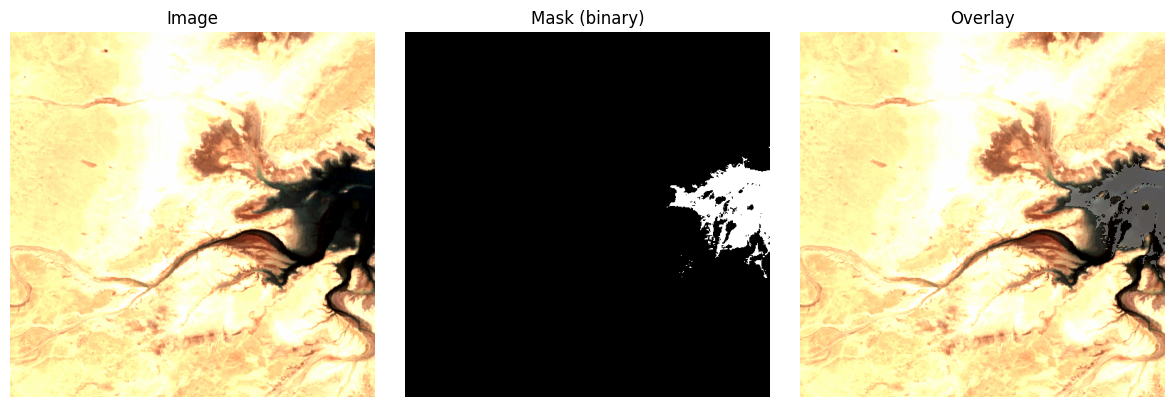

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.03725433349609375


In [ ]:
# Show example train image

fname = "tharthar_2021_r015_c008.npy"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir3, split, "images", fname)
mask_path = os.path.join(base_dir3, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

In [ ]:
# =========================
# PRE-PROCESS DATA: NO TRANSPOSE FOR 4-BAND DATA
# =========================

# Images: just ensure float32, no transpose
for i in range(len(training_images3)):
    training_images3[i] = training_images3[i].astype('float32')

for i in range(len(validation_images3)):
    validation_images3[i] = validation_images3[i].astype('float32')

for i in range(len(test_images3)):
    test_images3[i] = test_images3[i].astype('float32')

# Masks: just ensure correct shape, no transpose
for i in range(len(training_masks3)):
    if training_masks3[i].ndim == 2:
        training_masks3[i] = training_masks3[i][..., np.newaxis]  # (512, 512, 1)

for i in range(len(validation_masks3)):
    if validation_masks3[i].ndim == 2:
        validation_masks3[i] = validation_masks3[i][..., np.newaxis]

for i in range(len(test_masks3)):
    if test_masks3[i].ndim == 2:
        test_masks3[i] = test_masks3[i][..., np.newaxis]

# Convert to numpy arrays
training_images3 = np.array(training_images3, dtype=np.float32)
training_masks3 = np.array(training_masks3, dtype=np.uint8)

validation_images3 = np.array(validation_images3, dtype=np.float32)
validation_masks3 = np.array(validation_masks3, dtype=np.uint8)

test_images3 = np.array(test_images3, dtype=np.float32)
test_masks3 = np.array(test_masks3, dtype=np.uint8)

# =========================
# VERIFY FINAL SHAPES
# =========================

print("\n" + "="*60)
print("AFTER PREPROCESSING:")
print("="*60)
print(f"Training images shape: {training_images3.shape}")  # Should be (N, 512, 512, 4)
print(f"Training masks shape: {training_masks3.shape}")    # Should be (N, 512, 512, 1)
print(f"Validation images shape: {validation_images3.shape}")
print(f"Validation masks shape: {validation_masks3.shape}")
print(f"Test images shape: {test_images3.shape}")
print(f"Test masks shape: {test_masks3.shape}")
print("="*60)



AFTER PREPROCESSING:
Training images shape: (250, 512, 512, 4)
Training masks shape: (250, 512, 512, 1)
Validation images shape: (56, 512, 512, 4)
Validation masks shape: (56, 512, 512, 1)
Test images shape: (20, 512, 512, 4)
Test masks shape: (20, 512, 512, 1)


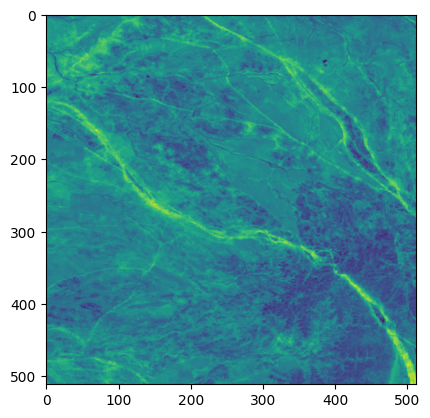

In [ ]:
# Plot example training image first band
plt.imshow(training_images3[0].reshape(512,512,4)[:,:,0])

In [ ]:
# Create TensorFlow datasets for training and validation sets (Lakes)
train_df_4band_lakes = tf.data.Dataset.from_tensor_slices((training_images3[0:250], training_masks3[0:250]))
train_df_4band_lakes = train_df_4band_lakes.batch(1)

validation_df_4band_lakes = tf.data.Dataset.from_tensor_slices((validation_images3, validation_masks3))
validation_df_4band_lakes = validation_df_4band_lakes.batch(1)

# Models

## U-Net

In [ ]:
'''
  Convolutional block with set parameters and activation layer after
'''

def convBlock(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    #conv = ZeroPadding2D((1,1))(input)
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
  else:
    #conv = ZeroPadding2D((1,1))(input)
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)

  conv = Activation(act)(conv)
  return conv

'''
  U-Net model
'''

def UNet(trained_weights = None, input_size = (512,512,4), drop_rate = 0.25, lr=0.0001):

    ## Can add pretrained weights by specifying 'trained_weights'

    # Input layer
    inputs = Input(input_size)

    ## Contraction phase
    conv1 = convBlock(inputs, 64, 3)
    conv1 = convBlock(conv1, 64, 3)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = convBlock(pool1, 128, 3)
    conv2 = convBlock(conv2, 128, 3)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    #drop2 = Dropout(drop_rate)(pool2)

    conv3 = convBlock(pool2, 256, 3)
    conv3 = convBlock(conv3, 256, 3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    #drop3 = Dropout(drop_rate)(pool3)

    conv4 = convBlock(pool3, 512, 3)
    conv4 = convBlock(conv4, 512, 3)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)
    #drop4 = Dropout(drop_rate)(pool4)

    conv5 = convBlock(pool4, 1024, 3)
    conv5 = convBlock(conv5, 1024, 3)

    ## Expansion phase
    up6 = (Conv2DTranspose(512, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5))
    merge6 = concatenate([conv4,up6])
    conv6 = convBlock(merge6, 512, 3)
    conv6 = convBlock(conv6, 512, 3)
    #conv6 = Dropout(drop_rate)(conv6)

    up7 = (Conv2DTranspose(256, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6))
    merge7 = concatenate([conv3,up7])
    conv7 = convBlock(merge7, 256, 3)
    conv7 = convBlock(conv7, 256, 3)
    #conv7 = Dropout(drop_rate)(conv7)

    up8 = (Conv2DTranspose(128, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv7))
    merge8 = concatenate([conv2,up8])
    conv8 = convBlock(merge8, 128, 3)
    conv8 = convBlock(conv8, 128, 3)
    #conv8 = Dropout(drop_rate)(conv8)

    up9 = (Conv2DTranspose(64, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv8))
    merge9 = concatenate([conv1,up9])
    conv9 = convBlock(merge9, 64, 3)
    conv9 = convBlock(conv9, 64, 3)

    # Output layer
    conv10 = convBlock(conv9, 1, 1, act='sigmoid')

    model = Model(inputs, conv10)

    model.compile(optimizer = Adam(learning_rate = lr), loss = 'binary_crossentropy', metrics = ['accuracy', 'mse'])

    if trained_weights != None:
    	model.load_weights(trained_weights)

    return model

In [ ]:
# Print model layers and number of parameters
UNet().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ conv2d_3[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 128, 128,  │          0 │ conv2d_4[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    590,080 │ activation_4[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_2[

 Total params: 31,032,321 (118.38 MB)

 Trainable params: 31,032,321 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

## Attention U-Net

In [ ]:
'''
  Convolutional block with two conv layers and two activation layers
'''

def convBlock2(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(conv)
    conv = Activation(act)(conv)
  else:
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(conv)
    conv = Activation(act)(conv)

  return conv

'''
  Attention block/mechanism
'''
def attention_block(x, gating, inter_shape, drop_rate=0.25):

    # Find shape of inputs
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

    ## Process x vector and gating signal
    # x vector input and processing
    theta_x = Conv2D(inter_shape, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(x)
    theta_x = MaxPooling2D((2,2))(theta_x)
    shape_theta_x = K.int_shape(theta_x)

    # gating signal ""
    phi_g = Conv2D(inter_shape, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(gating)
    shape_phi_g = K.int_shape(phi_g)

    # Add components
    concat_xg = add([phi_g, theta_x])
    act_xg = Activation('relu')(concat_xg)

    # Apply convolution
    psi = Conv2D(1, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(act_xg)

    # Apply sigmoid activation
    sigmoid_xg = Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)

    # UpSample and resample to correct size
    upsample_psi = UpSampling2D(interpolation='bilinear', size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)
    y = multiply([upsample_psi, x])

    return y


'''
  Attention U-Net model
'''

def UNetAM(trained_weights = None, input_size = (512,512,3), drop_rate = 0.25, lr=0.0001, filter_base=16):

    ## Can add pretrained weights by specifying 'trained_weights'

    # Input layer
    inputs = Input(input_size, batch_size=1)

    ## Contraction phase
    conv = convBlock2(inputs, filter_base, 3)
    #conv0 = Dropout(drop_rate)(conv0)

    conv0 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv0 = convBlock2(conv0, 2 * filter_base, 3)

    pool0 = MaxPooling2D(pool_size=(2, 2))(conv0)
    conv1 = convBlock2(pool0, 4 * filter_base, 3)
    #conv1 = Dropout(drop_rate)(conv1)

    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = convBlock2(pool1, 8 * filter_base, 3)
    #conv2 = Dropout(drop_rate)(conv2)

    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = convBlock2(pool2, 16 * filter_base, 3)
    #conv3 = Dropout(drop_rate)(conv3)

    ## Expansion phase
    up4 = (Conv2DTranspose(8 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv3))
    merge4 = attention_block(conv2, conv3, 8 * filter_base, drop_rate) # Attention gate
    conv4 = concatenate([up4, merge4])
    conv4 = convBlock2(conv4, 8 * filter_base, 3)

    up5 = (Conv2DTranspose(4 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv4))
    merge5 = attention_block(conv1, conv4, 4 * filter_base, drop_rate) # Attention gate
    conv5 = concatenate([up5, merge5])
    conv5 = convBlock2(conv5, 4 * filter_base, 3)

    up6 = (Conv2DTranspose(2 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5))
    merge6 = attention_block(conv0, conv5, 2 * filter_base, drop_rate) # Attention gate
    conv6 = concatenate([up6, merge6])
    conv6 = convBlock2(conv6, 2 * filter_base, 3)

    up7 = (Conv2DTranspose(1 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6))
    merge7 = attention_block(conv, conv6, 1 * filter_base, drop_rate) # Attention gate
    conv7 = concatenate([up7, merge7])
    conv7 = concatenate([up7, conv])
    conv7 = convBlock2(conv7, 1 * filter_base, 3)

    ## Output layer
    out = convBlock(conv7, 1, 1, act='sigmoid')

    model = Model(inputs, out)

    model.compile(optimizer = Adam(learning_rate = lr), loss = binary_crossentropy, metrics = ['accuracy', 'mse'])

    if trained_weights != None:
    	model.load_weights(trained_weights)

    return model

In [ ]:
# Print model layers and number of parameters
UNetAM().summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (1, 512, 512, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (1, 512, 512, 16) │        448 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (1, 512, 512, 16) │          0 │ conv2d_19[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (1, 512, 512, 16) │      2,320 │ activation_19[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (1, 512, 512, 16) │          0 │ conv2d_20[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (1, 256, 256, 16) │          0 │ activation_20[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (1, 256, 256, 32) │      4,640 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (1, 256, 256, 32) │          0 │ conv2d_21[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (1, 256, 256, 32) │      9,248 │ activation_21[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (1, 256, 256, 32) │          0 │ conv2d_22[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (1, 128, 128, 32) │          0 │ activation_22[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (1, 128, 128, 64) │     18,496 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (1, 128, 128, 64) │          0 │ conv2d_23[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (1, 128, 128, 64) │     36,928 │ activation_23[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (1, 128, 128, 64) │          0 │ conv2d_24[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (1, 64, 64, 64)   │          0 │ activation_24[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (1, 64, 64, 128)  │     73,856 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (1, 64, 64, 128)  │          0 │ conv2d_25[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (1, 64, 64, 128)  │    147,584 │ activation_25[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,006,292 (7.65 MB)

 Trainable params: 2,006,292 (7.65 MB)

 Non-trainable params: 0 (0.00 B)

# Train on RGB feature data

## U-Net

In [ ]:
# Train U-Net with generator
model_unet = UNet(input_size=(512,512,3), lr=0.0001)
save_model = ModelCheckpoint('unet-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1,  X_train, Y_train, data_gen_args, save_to_dir=None)

model_unet.fit(train, steps_per_epoch=100, epochs=30, validation_data=validation_df, callbacks=[save_model])

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7920 - loss: 0.4929 - mse: 0.1681
Epoch 1: val_accuracy improved from -inf to 0.94140, saving model to unet-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 182ms/step - accuracy: 0.7927 - loss: 0.4917 - mse: 0.1677 - val_accuracy: 0.9414 - val_loss: 0.5782 - val_mse: 0.0584
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9162 - loss: 0.2636 - mse: 0.0690
Epoch 2: val_accuracy improved from 0.94140 to 0.94140, saving model to unet-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.9162 - loss: 0.2632 - mse: 0.0690 - val_accuracy: 0.9414 - val_loss: 0.1430 - val_mse: 0.0422
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8911 - loss: 0.2312 - mse: 0.0731
Epoch 3: val_accuracy improved from 0.94140 to 0.94914, saving model to unet-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.8908 - loss: 0.2314 - mse: 0.0731 - val_accuracy: 0.9491 - val_loss: 0.1268 -

In [ ]:
# Save model training history
np.save('unet-3d-history.npy',model_unet.history)


In [ ]:
# Copy models to drive
!cp unet-3d.keras drive/MyDrive/Diss/
!cp unet-3d-history.npy drive/MyDrive/Diss/

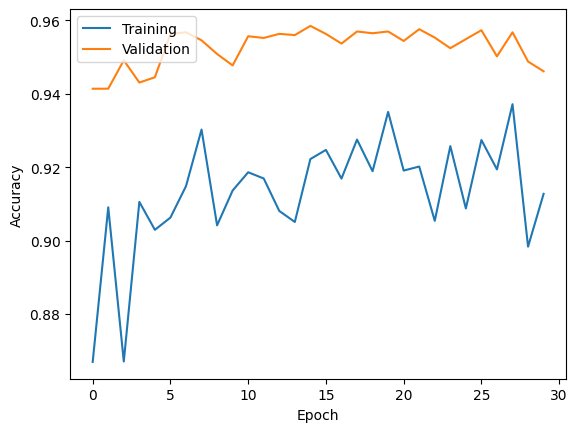

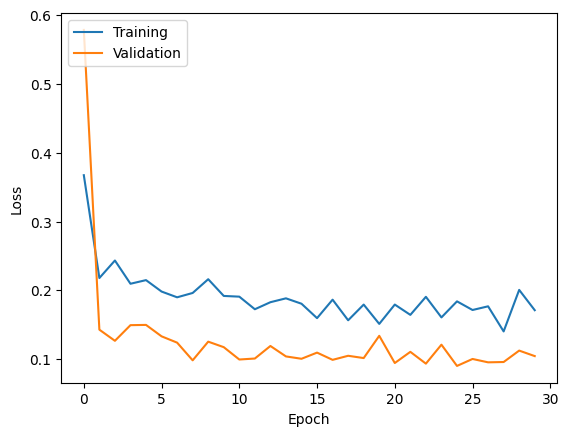

In [ ]:
# Plot accuracy and loss

## Accuracy
plt.plot(model_unet.history.history['accuracy'])
plt.plot(model_unet.history.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(model_unet.history.history['loss'])
plt.plot(model_unet.history.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

## Attention U-Net

In [ ]:
# Train Attention U-Net with generator
model_attention_unet = UNetAM(lr=0.0005, filter_base=16)
save_model_am = ModelCheckpoint('unet-attention-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1,  X_train, Y_train, data_gen_args, save_to_dir=None)
model_attention_unet.fit(train, steps_per_epoch=100, epochs=50, validation_data = validation_df, callbacks=[save_model_am])

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7216 - loss: 0.5560 - mse: 0.1906
Epoch 1: val_accuracy improved from -inf to 0.94139, saving model to unet-attention-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 119ms/step - accuracy: 0.7228 - loss: 0.5545 - mse: 0.1900 - val_accuracy: 0.9414 - val_loss: 0.4502 - val_mse: 0.0535
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9162 - loss: 0.2588 - mse: 0.0708
Epoch 2: val_accuracy improved from 0.94139 to 0.94140, saving model to unet-attention-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9162 - loss: 0.2584 - mse: 0.0708 - val_accuracy: 0.9414 - val_loss: 0.1481 - val_mse: 0.0428
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8911 - loss: 0.2440 - mse: 0.0770
Epoch 3: val_accuracy improved from 0.94140 to 0.95554, saving model to unet-attention-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8908 - loss: 0.2441 - mse: 0.0771 - val_accuracy: 0.95

In [ ]:
# Save model history
np.save('unet-attention-3d-history.npy',model_attention_unet.history)

In [ ]:
# Copy models to drive
!cp unet-attention-3d.keras drive/MyDrive/Diss/
!cp unet-attention-3d-history.npy drive/MyDrive/Diss/

# Train on 4-band data

## Train on 4-band Marshes data

### U-Net

In [ ]:
# Train U-Net with generator
model_unet_4band = UNet()
save_model_4band = ModelCheckpoint('unet-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_unet_4band.fit(train_df_4band_marshes, epochs=20, validation_data = validation_df_4band_marshes, callbacks=[save_model_4band])

Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8761 - loss: 0.2941 - mse: 0.0992
Epoch 1: val_accuracy improved from -inf to 0.98703, saving model to unet-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - accuracy: 0.8764 - loss: 0.2935 - mse: 0.0989 - val_accuracy: 0.9870 - val_loss: 0.0387 - val_mse: 0.0107
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9756 - loss: 0.0710 - mse: 0.0198
Epoch 2: val_accuracy improved from 0.98703 to 0.98926, saving model to unet-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - accuracy: 0.9756 - loss: 0.0709 - mse: 0.0198 - val_accuracy: 0.9893 - val_loss: 0.0334 - val_mse: 0.0085
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9816 - loss: 0.0477 - mse: 0.0138
Epoch 3: val_accuracy improved from 0.98926 to 0.98973, saving model to unet-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.9816 - loss: 0.0476 - mse: 0.0138 - val_accuracy: 0.9897 - val_loss: 0.0337 -

In [ ]:
# Save model history
np.save('unet-4d-history.npy',model_unet_4band.history.history)

In [ ]:
# Copy models to drive
!cp unet-4d.keras drive/MyDrive/Diss/
!cp unet-4d-history.npy drive/MyDrive/Diss/

### Attention U-Net

In [ ]:
# Train U-Net with generator
model_attention_unet_4band = UNetAM(input_size=(512,512,4), filter_base=16, lr=0.0005)
save_model_4band_attention = ModelCheckpoint('unet-attention-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_attention_unet_4band.fit(train_df_4band_marshes, epochs = 60, validation_data = validation_df_4band_marshes, callbacks=[save_model_4band_attention])

Epoch 1/60
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8949 - loss: 0.2770 - mse: 0.0913
Epoch 1: val_accuracy improved from -inf to 0.98872, saving model to unet-attention-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.8957 - loss: 0.2753 - mse: 0.0907 - val_accuracy: 0.9887 - val_loss: 0.0367 - val_mse: 0.0089
Epoch 2/60
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9803 - loss: 0.0522 - mse: 0.0148
Epoch 2: val_accuracy improved from 0.98872 to 0.98954, saving model to unet-attention-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9803 - loss: 0.0521 - mse: 0.0148 - val_accuracy: 0.9895 - val_loss: 0.0316 - val_mse: 0.0081
Epoch 3/60
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9824 - loss: 0.0445 - mse: 0.0130
Epoch 3: val_accuracy improved from 0.98954 to 0.99035, saving model to unet-attention-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9824 - loss: 0.0444 - mse: 0.0130 - val_accuracy: 0.990

In [ ]:
# Save model history
np.save('unet-attention-4d-history.npy',model_attention_unet_4band.history.history)

In [ ]:
# Copy models to drive
!cp unet-attention-4d.keras drive/MyDrive/Diss/
!cp unet-attention-4d-history.npy drive/MyDrive/Diss/

## Train on 4-band Lakes data

### U-Net

In [ ]:
# Train U-Net with generator
model_unet_4band_lakes = UNet()
save_model_4band_lakes = ModelCheckpoint('unet-4d-lakes.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_unet_4band_lakes.fit(train_df_4band_lakes, epochs = 20, validation_data = validation_df_4band_lakes, callbacks=[save_model_4band_lakes])

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8485 - loss: 0.3060 - mse: 0.1051
Epoch 1: val_accuracy improved from -inf to 0.99354, saving model to unet-4d-lakes.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step - accuracy: 0.8489 - loss: 0.3053 - mse: 0.1049 - val_accuracy: 0.9935 - val_loss: 0.0183 - val_mse: 0.0051
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9964 - loss: 0.0128 - mse: 0.0029
Epoch 2: val_accuracy improved from 0.99354 to 0.99446, saving model to unet-4d-lakes.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - accuracy: 0.9964 - loss: 0.0128 - mse: 0.0029 - val_accuracy: 0.9945 - val_loss: 0.0174 - val_mse: 0.0045
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9969 - loss: 0.0108 - mse: 0.0024
Epoch 3: val_accuracy improved from 0.99446 to 0.99515, saving model to unet-4d-lakes.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - accuracy: 0.9969 - loss: 0.0108 - mse: 0.0024 - val_accuracy: 0.9951 - 

In [ ]:
# Save model history
np.save('unet-4d-lakes-history.npy',model_unet_4band_lakes.history.history)

In [ ]:
# Copy models to drive
!cp unet-4d-lakes.keras drive/MyDrive/Diss/
!cp unet-4d-lakes-history.npy drive/MyDrive/Diss/

### Attention U-Net

In [ ]:
# Train Attention U-Net with generator
model_attention_unet_4band_lakes = UNetAM(input_size=(512,512,4), filter_base=16, lr=0.0005)
save_model_4band_attention_lakes = ModelCheckpoint('unet-attention-4d-lakes.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_attention_unet_4band_lakes.fit(train_df_4band_lakes, epochs = 60, validation_data = validation_df_4band_lakes, callbacks=[save_model_4band_attention_lakes])

Epoch 1/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7801 - loss: 0.5579 - mse: 0.1618
Epoch 1: val_accuracy improved from -inf to 0.98956, saving model to unet-attention-4d-lakes.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.7804 - loss: 0.5571 - mse: 0.1616 - val_accuracy: 0.9896 - val_loss: 0.0466 - val_mse: 0.0110
Epoch 2/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9928 - loss: 0.0253 - mse: 0.0059
Epoch 2: val_accuracy improved from 0.98956 to 0.99209, saving model to unet-attention-4d-lakes.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9928 - loss: 0.0253 - mse: 0.0059 - val_accuracy: 0.9921 - val_loss: 0.0233 - val_mse: 0.0063
Epoch 3/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9950 - loss: 0.0156 - mse: 0.0038
Epoch 3: val_accuracy improved from 0.99209 to 0.99346, saving model to unet-attention-4d-lakes.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9950 - loss: 0.0156 - mse: 0.0038 - v

In [ ]:
# Save model history
np.save('unet-attention-4d-lakes-history.npy',model_attention_unet_4band_lakes.history.history)

In [ ]:
# Copy models to drive
!cp unet-attention-4d-lakes.keras drive/MyDrive/Diss/
!cp unet-attention-4d-lakes-history.npy drive/MyDrive/Diss/

# Import Models and Compute Metrics

## RGB

In [ ]:
# Load 3-dim models and history stats
attention_unet = load_model('unet-attention-3d.keras')
unet = load_model('unet-3d.keras')

unet_history = np.load('unet-3d-history.npy', allow_pickle='TRUE').item()
attention_unet_history = np.load('unet-attention-3d-history.npy', allow_pickle='TRUE').item()

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9331 - loss: 0.1480 - mse: 0.0468
Epoch 1: val_accuracy did not improve from 0.95851
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.9331 - loss: 0.1479 - mse: 0.0468 - val_accuracy: 0.9460 - val_loss: 0.1507 - val_mse: 0.0403
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9025 - loss: 0.2028 - mse: 0.0654
Epoch 2: val_accuracy did not improve from 0.95851
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - accuracy: 0.9027 - loss: 0.2025 - mse: 0.0653 - val_accuracy: 0.9545 - val_loss: 0.0951 - val_mse: 0.0301
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8991 - loss: 0.1896 - mse: 0.0632
Epoch 3: val_accuracy did not improve from 0.95851
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - accuracy: 0.8992 - loss: 0.1896 - mse: 0.0632 - val_accuracy: 0.9543 - val_loss: 0.0903 - val_mse: 0.0289
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9326 - loss: 0.15

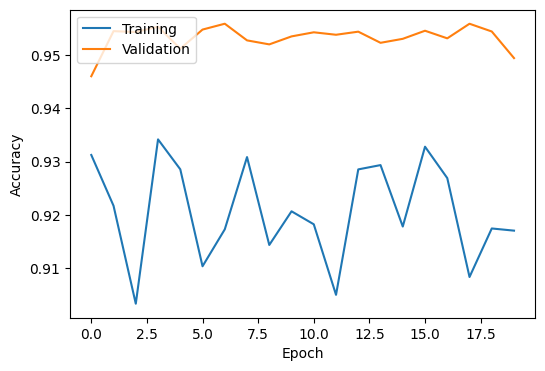

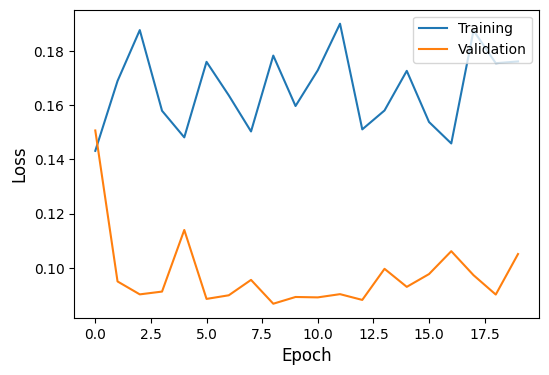

In [ ]:
# Plot accuracy and loss for U-Net
unet_history_obj = model_unet.fit(train, steps_per_epoch=100, epochs=20, validation_data=validation_df, callbacks=[save_model])
unet_history = unet_history_obj.history
## Accuracy
plt.figure(figsize=(6, 4))
plt.plot(unet_history['accuracy'])
plt.plot(unet_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.figure(figsize=(6, 4))
plt.plot(unet_history['loss'])
plt.plot(unet_history['val_loss'])
plt.ylabel('Loss', size=12)
plt.xlabel('Epoch', size=12)
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

In [ ]:
# Scores of each model
unet_score = (score_eval(unet, validation_images, validation_masks))
am_unet_score = (score_eval(attention_unet, validation_images, validation_masks))

In [ ]:
# Process one image at a time
def evaluate_one_by_one(model, X, Y, eval_func):
    """Evaluate each sample individually and average results."""
    results = []
    num_samples = len(X)

    for i in range(num_samples):
        x_single = X[i:i+1]  # Shape: (1, 512, 512, 3)
        y_single = Y[i:i+1]  # Shape: (1, 512, 512, 1)

        result = eval_func(model, x_single, y_single)
        results.append(result)

        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{num_samples} samples...")

    return np.mean(results)


# Precision and recall of each model (one at a time)
print("Evaluating U-Net precision...")
unet_precision = evaluate_one_by_one(unet, X_val, Y_val, precision_eval)

print("\nEvaluating U-Net recall...")
unet_recall = evaluate_one_by_one(unet, X_val, Y_val, recall_eval)

print("\nEvaluating Attention U-Net precision...")
am_unet_precision = evaluate_one_by_one(attention_unet, X_val, Y_val, precision_eval)

print("\nEvaluating Attention U-Net recall...")
am_unet_recall = evaluate_one_by_one(attention_unet, X_val, Y_val, recall_eval)

print(f"\nU-Net - Precision: {unet_precision:.4f}, Recall: {unet_recall:.4f}")
print(f"Attention U-Net - Precision: {am_unet_precision:.4f}, Recall: {am_unet_recall:.4f}")


Evaluating U-Net precision...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...

Evaluating U-Net recall...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...

Evaluating Attention U-Net precision...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...

Evaluating Attention U-Net recall...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...

In [ ]:
# F1-scores of each model
unet_f1_score = f1_score_eval_basic(unet_precision, unet_recall)
am_unet_f1_score = f1_score_eval_basic(am_unet_precision, am_unet_recall)

print(f"U-Net F1-Score: {unet_f1_score:.4f}")
print(f"Attention U-Net F1-Score: {am_unet_f1_score:.4f}")

U-Net F1-Score: 0.9603
Attention U-Net F1-Score: 0.9600


In [ ]:
# Print score eval results for each model
print('U-Net accuracy: ', np.mean(unet_score), np.std(unet_score))
print('Attention U-Net accuracy: ', np.mean(am_unet_score), np.std(am_unet_score))

U-Net accuracy:  0.958510504828559 0.1007349719545272
Attention U-Net accuracy:  0.9576711943655303 0.10022081046678621


In [ ]:
# Print precision eval results for each model

print(f"\nU-Net - Precision: {unet_precision:.4f}, Recall: {unet_recall:.4f}")
print(f"Attention U-Net - Precision: {am_unet_precision:.4f}, Recall: {am_unet_recall:.4f}")


U-Net - Precision: 0.9621, Recall: 0.9585
Attention U-Net - Precision: 0.9624, Recall: 0.9576


In [ ]:
# Print recall eval results for each model
print('U-Net recall: ', np.mean(unet_recall), np.std(unet_recall))
print('Attention U-Net recall: ', np.mean(am_unet_recall), np.std(am_unet_recall))

U-Net recall:  0.9585108516192196 0.0
Attention U-Net recall:  0.9576110454520794 0.0


In [ ]:
# Print f1-score eval results for each model
print('U-Net F1-score: ', np.mean(unet_f1_score))
print('Attention U-Net F1-score: ', np.mean(am_unet_f1_score))

U-Net F1-score:  0.9603154334005094
Attention U-Net F1-score:  0.9600205415122398


## 4-band

### Marshes Data

In [ ]:
# Load 4-dim models and history stats
attention_unet_4d = load_model('unet-attention-4d.keras')
unet_4d = load_model('unet-4d.keras')

unet_4d_history = np.load('unet-4d-history.npy', allow_pickle='TRUE').item()
attention_unet_4d_history = np.load('unet-attention-4d-history.npy', allow_pickle='TRUE').item()

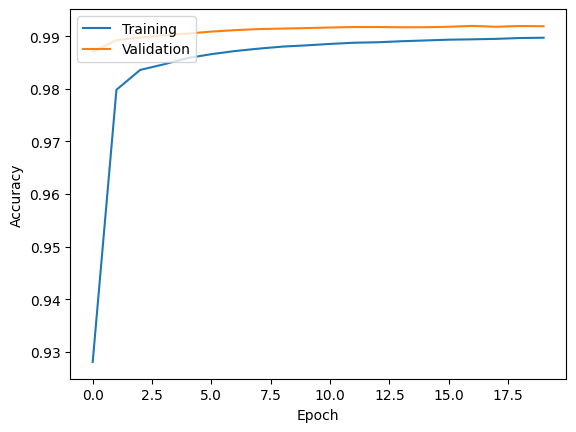

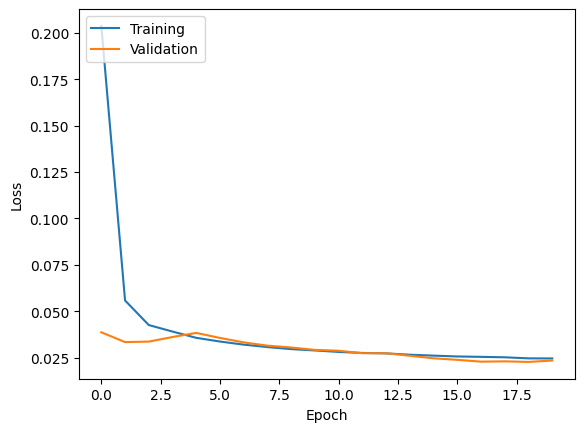

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_4d_history['accuracy'])
plt.plot(unet_4d_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_4d_history['loss'])
plt.plot(unet_4d_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

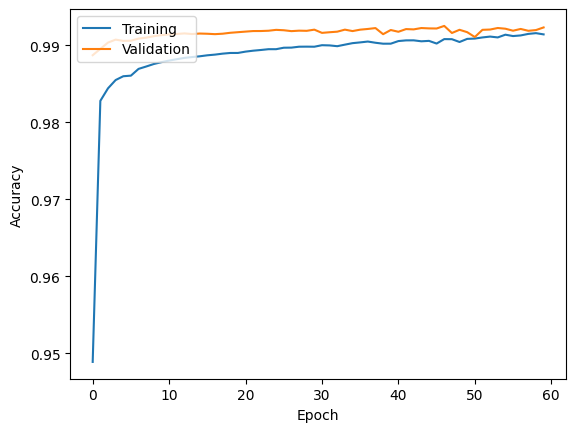

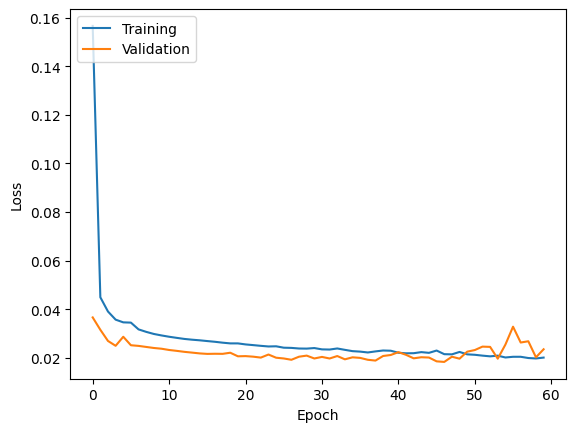

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_4d_history['accuracy'])
plt.plot(attention_unet_4d_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(attention_unet_4d_history['loss'])
plt.plot(attention_unet_4d_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Scores of each model
print("Evaluating U-Net scores...")
unet_4d_score = evaluate_one_by_one(unet_4d, validation_images2, validation_masks2, score_eval2)

print("\nEvaluating Attention U-Net scores...")
am_unet_4d_score = evaluate_one_by_one(attention_unet_4d, validation_images2, validation_masks2, score_eval2)

print(f"\nU-Net mean score: {unet_4d_score:.4f}")
print(f"Attention U-Net mean score: {am_unet_4d_score:.4f}")

Evaluating U-Net scores...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...

Evaluating Attention U-Net scores...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...

U-Net mean score: 0.9920
Attention U-Net mean score: 0.9925


In [ ]:

def evaluate_one_by_one_segmentation(model, X, Y, thresh=0.5):
    tp = fp = fn = 0
    num_samples = len(X)

    for i in range(num_samples):
        x = X[i:i+1]   # (1, H, W, C)
        y = Y[i:i+1]   # (1, H, W, 1)

        y_prob = model.predict(x, verbose=0)
        y_pred = (y_prob > thresh).astype(np.uint8)
        y_true = (y > 0.5).astype(np.uint8)

        yp = y_pred.reshape(-1)
        yt = y_true.reshape(-1)

        tp += np.sum((yp == 1) & (yt == 1))
        fp += np.sum((yp == 1) & (yt == 0))
        fn += np.sum((yp == 0) & (yt == 1))

        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{num_samples} samples...")

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1

In [ ]:
# Precision and recall of each model
unet_4d_precision = evaluate_one_by_one(
    unet_4d, validation_images2, validation_masks2, precision_eval
)

am_unet_4d_precision = evaluate_one_by_one(
    attention_unet_4d, validation_images2, validation_masks2, precision_eval
)

unet_4d_recall = evaluate_one_by_one(
    unet_4d, validation_images2, validation_masks2, recall_eval
)

am_unet_4d_recall = evaluate_one_by_one(
    attention_unet_4d, validation_images2, validation_masks2, recall_eval
)


Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...


In [ ]:
# F1-scores of each model
unet_4d_f1_score = (f1_score_eval_basic(unet_4d_precision, unet_4d_recall))
am_unet_4d_f1_score = (f1_score_eval_basic(am_unet_4d_precision, am_unet_4d_recall))

In [ ]:
# Print score eval results for each model
print('U-Net accuracy: ', np.mean(unet_4d_score), np.std(unet_4d_score))
print('Attention U-Net accuracy: ', np.mean(am_unet_4d_score), np.std(am_unet_4d_score))

U-Net accuracy:  0.9919581557765151 0.0
Attention U-Net accuracy:  0.9925175291119199 0.0


In [ ]:
# Print precision eval results for each model
print('U-Net precision: ', np.mean(unet_4d_precision), np.std(unet_4d_precision))
print('Attention U-Net precision: ', np.mean(am_unet_4d_precision), np.std(am_unet_4d_precision))

U-Net precision:  0.9923622217279561 0.0
Attention U-Net precision:  0.9927556985485402 0.0


In [ ]:
# Print recall eval results for each model
print('U-Net recall: ', np.mean(unet_4d_recall), np.std(unet_4d_recall))
print('Attention U-Net recall: ', np.mean(am_unet_4d_recall), np.std(am_unet_4d_recall))

U-Net recall:  0.9919581557765151 0.0
Attention U-Net recall:  0.9925175291119199 0.0


In [ ]:
# Print f1-score eval results for each model
print('U-Net F1-score: ', np.mean(unet_4d_f1_score))
print('Attention U-Net F1-score: ', np.mean(am_unet_4d_f1_score))

U-Net F1-score:  0.9921601476123838
Attention U-Net F1-score:  0.9926365995438639


### Marshes on unseen Lakes data

In [ ]:

# Score
unet_marshes_on_lakes_score = score_eval2(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_score = score_eval2(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# Precision
unet_marshes_on_lakes_precision = precision_eval(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_precision = precision_eval(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# Recall
unet_marshes_on_lakes_recall = recall_eval(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_recall = recall_eval(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# F1-scores
unet_marshes_on_lakes_f1_score = f1_score_eval_basic(
    unet_marshes_on_lakes_precision,
    unet_marshes_on_lakes_recall
)
am_unet_marshes_on_lakes_f1_score = f1_score_eval_basic(
    am_unet_marshes_on_lakes_precision,
    am_unet_marshes_on_lakes_recall
)

In [ ]:
# Score
unet_marshes_on_lakes_score = score_eval2(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_score = score_eval2(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# Precision
unet_marshes_on_lakes_precision = precision_eval(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_precision = precision_eval(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# Recall
unet_marshes_on_lakes_recall = recall_eval(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_recall = recall_eval(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# F1-scores of each model
unet_marshes_on_lakes_f1_score = f1_score_eval_basic(
    unet_marshes_on_lakes_precision,
    unet_marshes_on_lakes_recall
)
am_unet_marshes_on_lakes_f1_score = f1_score_eval_basic(
    am_unet_marshes_on_lakes_precision,
    am_unet_marshes_on_lakes_recall
)

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_marshes_on_lakes_score), np.std(unet_marshes_on_lakes_score))
print('Attention U-Net score: ', np.mean(am_unet_marshes_on_lakes_score), np.std(am_unet_marshes_on_lakes_score))

print('U-Net precision: ', np.mean(unet_marshes_on_lakes_precision), np.std(unet_marshes_on_lakes_precision))
print('Attention U-Net precision: ', np.mean(am_unet_marshes_on_lakes_precision), np.std(am_unet_marshes_on_lakes_precision))

print('U-Net recall: ', np.mean(unet_marshes_on_lakes_recall), np.std(unet_marshes_on_lakes_recall))
print('Attention U-Net recall: ', np.mean(am_unet_marshes_on_lakes_recall), np.std(am_unet_marshes_on_lakes_recall))

print('U-Net F1-score: ', unet_marshes_on_lakes_f1_score)
print('Attention U-Net F1-score: ', am_unet_marshes_on_lakes_f1_score)

U-Net score:  0.9967658896195261 0.006210652133461775
Attention U-Net score:  0.9964815942864669 0.0069271398775714145
U-Net precision:  0.9968976192855417 0.005842130510783073
Attention U-Net precision:  0.9966507447954579 0.006466096500184144
U-Net recall:  0.9967658896195261 0.006210652133461775
Attention U-Net recall:  0.9964815942864669 0.0069271398775714145
U-Net F1-score:  0.9968317501005696
Attention U-Net F1-score:  0.996566162363342


### Lakes Data

In [ ]:
# Load 4-dim models and history stats
attention_unet_4d_lakes = load_model('unet-attention-4d-lakes.keras')
unet_4d_lakes = load_model('unet-4d-lakes.keras')

unet_4d_lakes_history = np.load('unet-4d-lakes-history.npy', allow_pickle='TRUE').item()
attention_unet_4d_lakes_history = np.load('unet-attention-4d-lakes-history.npy', allow_pickle='TRUE').item()

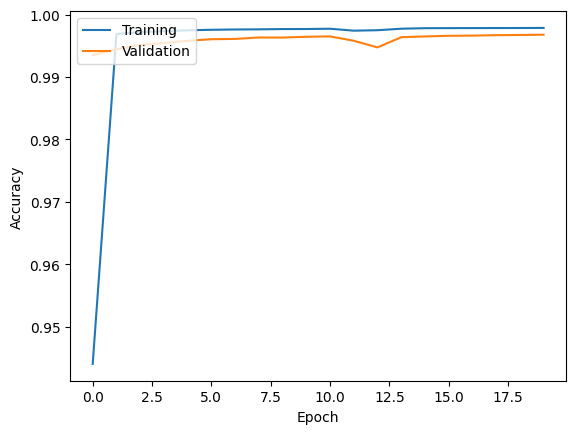

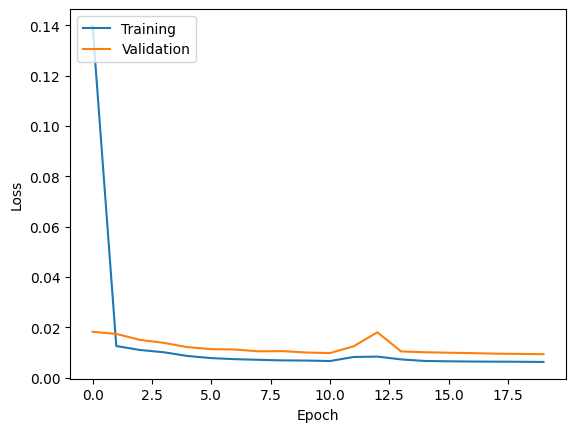

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_4d_lakes_history['accuracy'])
plt.plot(unet_4d_lakes_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_4d_lakes_history['loss'])
plt.plot(unet_4d_lakes_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

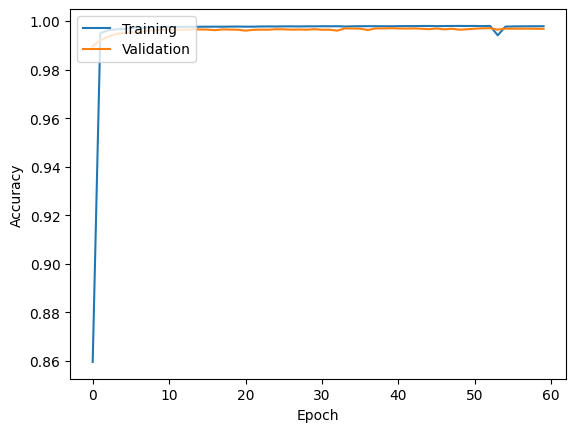

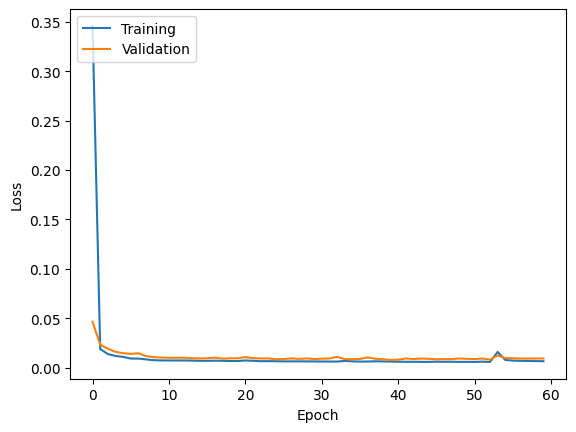

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_4d_lakes_history['accuracy'])
plt.plot(attention_unet_4d_lakes_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(attention_unet_4d_lakes_history['loss'])
plt.plot(attention_unet_4d_lakes_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Scores of each model
unet_4d_lakes_score = (score_eval2(unet_4d_lakes, validation_images3, validation_masks3))
am_unet_4d_lakes_score = (score_eval2(attention_unet_4d_lakes, validation_images3, validation_masks3))

# Precision and recall of each model
unet_4d_lakes_precision = (precision_eval(unet_4d_lakes, validation_images3, validation_masks3))
am_unet_4d_lakes_precision = (precision_eval(attention_unet_4d_lakes, validation_images3, validation_masks3))

unet_4d_lakes_recall = (recall_eval(unet_4d_lakes, validation_images3, validation_masks3))
am_unet_4d_lakes_recall = (recall_eval(attention_unet_4d_lakes, validation_images3, validation_masks3))

# F1-scores of each model
unet_4d_lakes_f1_score = (f1_score_eval_basic(unet_4d_lakes_precision, unet_4d_lakes_recall))
am_unet_4d_lakes_f1_score = (f1_score_eval_basic(am_unet_4d_lakes_precision, am_unet_4d_lakes_recall))

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_4d_lakes_score), np.std(unet_4d_lakes_score))
print('Attention U-Net score: ', np.mean(am_unet_4d_lakes_score), np.std(am_unet_4d_lakes_score))

print('U-Net precision: ', np.mean(unet_4d_lakes_precision), np.std(unet_4d_lakes_precision))
print('Attention U-Net precision: ', np.mean(am_unet_4d_lakes_precision), np.std(am_unet_4d_lakes_precision))

print('U-Net recall: ', np.mean(unet_4d_lakes_recall), np.std(unet_4d_lakes_recall))
print('Attention U-Net recall: ', np.mean(am_unet_4d_lakes_recall), np.std(am_unet_4d_lakes_recall))

print('U-Net F1-score: ', unet_4d_lakes_f1_score)
print('Attention U-Net F1-score: ', am_unet_4d_lakes_f1_score)

U-Net score:  0.9967848914010184 0.005582452576139748
Attention U-Net score:  0.9970240592956543 0.005019935430090632
U-Net precision:  0.9969137036706018 0.005309462218267282
Attention U-Net precision:  0.9971183147446342 0.004836404208494468
U-Net recall:  0.9967848914010184 0.005582452576139748
Attention U-Net recall:  0.9970240592956543 0.005019935430090632
U-Net F1-score:  0.9968492933745491
Attention U-Net F1-score:  0.9970711847925977


### Lakes on unseen Marshes data

In [ ]:
# Score
unet_lakes_on_marshes_score = score_eval2(
    unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)
am_unet_lakes_on_marshes_score = score_eval2(
    attention_unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)

# Precision
unet_lakes_on_marshes_precision = precision_eval(
    unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)
am_unet_lakes_on_marshes_precision = precision_eval(
    attention_unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)

# Recall
unet_lakes_on_marshes_recall = recall_eval(
    unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)
am_unet_lakes_on_marshes_recall = recall_eval(
    attention_unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)

# F1-scores of each model
unet_lakes_on_marshes_f1_score = f1_score_eval_basic(
    unet_lakes_on_marshes_precision,
    unet_lakes_on_marshes_recall
)
am_unet_lakes_on_marshes_f1_score = f1_score_eval_basic(
    am_unet_lakes_on_marshes_precision,
    am_unet_lakes_on_marshes_recall
)


In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_lakes_on_marshes_score), np.std(unet_lakes_on_marshes_score))
print('Attention U-Net score: ', np.mean(am_unet_lakes_on_marshes_score), np.std(am_unet_lakes_on_marshes_score))

print('U-Net precision: ', np.mean(unet_lakes_on_marshes_precision), np.std(unet_lakes_on_marshes_precision))
print('Attention U-Net precision: ', np.mean(am_unet_lakes_on_marshes_precision), np.std(am_unet_lakes_on_marshes_precision))

print('U-Net recall: ', np.mean(unet_lakes_on_marshes_recall), np.std(unet_lakes_on_marshes_recall))
print('Attention U-Net recall: ', np.mean(am_unet_lakes_on_marshes_recall), np.std(am_unet_lakes_on_marshes_recall))

print('U-Net F1-score: ', unet_lakes_on_marshes_f1_score)
print('Attention U-Net F1-score: ', am_unet_lakes_on_marshes_f1_score)

U-Net score:  0.989361995408515 0.024428138695816125
Attention U-Net score:  0.9883125689851135 0.02708675740386104
U-Net precision:  0.9906049958157422 0.019675309877379907
Attention U-Net precision:  0.989881480135169 0.021431668565019348
U-Net recall:  0.989361995408515 0.024428138695816125
Attention U-Net recall:  0.9883125689851135 0.02708675740386104
U-Net F1-score:  0.9899831054414795
Attention U-Net F1-score:  0.9890964024062636


### Marshes and Lakes unseen test data

In [ ]:
# Marshes trained model on Marshes test data
# Scores of each model
unet_4d_score_test = (score_eval2(unet_4d, test_images2, test_masks2))
am_unet_4d_score_test = (score_eval2(attention_unet_4d, test_images2, test_masks2))

# Precision and recall of each model
unet_4d_precision_test = (precision_eval(unet_4d, test_images2, test_masks2))
am_unet_4d_precision_test = (precision_eval(attention_unet_4d, test_images2, test_masks2))

unet_4d_recall_test = (recall_eval(unet_4d, test_images2, test_masks2))
am_unet_4d_recall_test = (recall_eval(attention_unet_4d, test_images2, test_masks2))

# F1-scores of each model
unet_4d_f1_score_test = (f1_score_eval_basic(unet_4d_precision_test, unet_4d_recall_test))
am_unet_4d_f1_score_test = (f1_score_eval_basic(am_unet_4d_precision_test, am_unet_4d_recall_test))

# Marshes trained model on Lakes test data
# Scores of each model
unet_4d_lakes_score_test = (score_eval2(unet_4d, test_images3, test_masks3))
am_unet_4d_lakes_score_test = (score_eval2(attention_unet_4d, test_images3, test_masks3))

# Precision and recall of each model
unet_4d_lakes_precision_test = (precision_eval(unet_4d, test_images3, test_masks3))
am_unet_4d_lakes_precision_test = (precision_eval(attention_unet_4d, test_images3, test_masks3))

unet_4d_lakes_recall_test = (recall_eval(unet_4d, test_images3, test_masks3))
am_unet_4d_lakes_recall_test = (recall_eval(attention_unet_4d, test_images3, test_masks3))

# F1-scores of each model
unet_4d_lakes_f1_score_test = (f1_score_eval_basic(unet_4d_lakes_precision_test, unet_4d_lakes_recall_test))
am_unet_4d_lakes_f1_score_test = (f1_score_eval_basic(am_unet_4d_lakes_precision_test, am_unet_4d_lakes_recall_test))

# Print metrics for Marshes on Marshes Test set
print('U-Net score (Marshes-trained on Marshes Test Data): ', np.mean(unet_4d_score_test), np.std(unet_4d_score_test))
print('Attention U-Net score (Marshes-trained on Marshes Test Data): ', np.mean(am_unet_4d_score_test), np.std(am_unet_4d_score_test))

# Print metrics for Marshes on Lakes Test set (CROSS-DATASET EVALUATION)
print('\nU-Net score (Marshes-trained on Lakes Test Data): ', np.mean(unet_4d_lakes_score_test), np.std(unet_4d_lakes_score_test))
print('Attention U-Net score (Marshes-trained on Lakes Test Data): ', np.mean(am_unet_4d_lakes_score_test), np.std(am_unet_4d_lakes_score_test))

U-Net score (Marshes-trained on Marshes Test Data):  0.9901981353759766 0.014335654478477263
Attention U-Net score (Marshes-trained on Marshes Test Data):  0.9905265808105469 0.013908764367919114

U-Net score (Marshes-trained on Lakes Test Data):  0.998630142211914 0.0024049138322765327
Attention U-Net score (Marshes-trained on Lakes Test Data):  0.9987573623657227 0.0021683756917176326


# Produce metric datasets for export

## RGB data

In [ ]:
scores = [unet_score, am_unet_score]
precision = [unet_precision, am_unet_precision]
recall = [unet_recall, am_unet_recall]
f1_scores = [unet_f1_score, am_unet_f1_score]

metrics = {'classifier': ['U-Net', 'Attention U-Net'],
           'accuracy': [np.mean(n) for n in scores],
           'precision': precision,
           'recall': recall,
           'f1_score': f1_scores,
           'accuracy_std': [np.std(n) for n in scores]
          }

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv('metrics_3d_marshes.csv', index=False)

# Display the results
print(metrics_df)

        classifier  accuracy  precision    recall  f1_score  accuracy_std
0            U-Net  0.958511   0.962127  0.958511  0.960315      0.100735
1  Attention U-Net  0.957671   0.962442  0.957611  0.960021      0.100221


## 4-band Marshes data

In [ ]:
scores_4d = [unet_4d_score, am_unet_4d_score]
precision_4d = [unet_4d_precision, am_unet_4d_precision]
recall_4d = [unet_4d_recall, am_unet_4d_recall]
f1_scores_4d = [unet_4d_f1_score, am_unet_4d_f1_score]

metrics_4d = {'classifier': ['U-Net', 'Attention U-Net'],
              'accuracy': [np.mean(n) for n in scores_4d],
              'precision': [np.mean(n) for n in precision_4d],
              'recall': [np.mean(n) for n in recall_4d],
              'f1_score': [np.mean(n) for n in f1_scores_4d],
              'accuracy_std': [np.std(n) for n in scores_4d],
              'precision_std': [np.std(n) for n in precision_4d],
              'recall_std': [np.std(n) for n in recall_4d]
              }
metrics_4d = pd.DataFrame(metrics_4d)
metrics_4d.to_csv('metrics_4d_marshes.csv', index=False)

# Display results
print(metrics_4d)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.991958   0.992362  0.991958  0.992160           0.0   
1  Attention U-Net  0.992518   0.992756  0.992518  0.992637           0.0   

   precision_std  recall_std  
0            0.0         0.0  
1            0.0         0.0  


## 4-band Lakes data

In [ ]:
scores_4d_lakes = [unet_4d_lakes_score, am_unet_4d_lakes_score]
precision_4d_lakes = [unet_4d_lakes_precision, am_unet_4d_lakes_precision]
recall_4d_lakes = [unet_4d_lakes_recall, am_unet_4d_lakes_recall]
f1_scores_4d_lakes = [unet_4d_lakes_f1_score, am_unet_4d_lakes_f1_score]

metrics_4d_lakes = {'classifier': ['U-Net', 'Attention U-Net'],
                    'accuracy': [np.mean(n) for n in scores_4d_lakes],
                    'precision': [np.mean(n) for n in precision_4d_lakes],
                    'recall': [np.mean(n) for n in recall_4d_lakes],
                    'f1_score': [np.mean(n) for n in f1_scores_4d_lakes],
                    'accuracy_std': [np.std(n) for n in scores_4d_lakes],
                    'precision_std': [np.std(n) for n in precision_4d_lakes],
                    'recall_std': [np.std(n) for n in recall_4d_lakes]
                    }
metrics_4d_lakes = pd.DataFrame(metrics_4d_lakes)
metrics_4d_lakes.to_csv('metrics_4d_lakes.csv', index=False)

# Display results
print(metrics_4d_lakes)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.996785   0.996914  0.996785  0.996849      0.005582   
1  Attention U-Net  0.997024   0.997118  0.997024  0.997071      0.005020   

   precision_std  recall_std  
0       0.005309    0.005582  
1       0.004836    0.005020  


## Test set data

In [ ]:
scores_4d_test = [unet_4d_score_test, am_unet_4d_score_test]
precision_4d_test = [unet_4d_precision_test, am_unet_4d_precision_test]
recall_4d_test = [unet_4d_recall_test, am_unet_4d_recall_test]
f1_scores_4d_test = [unet_4d_f1_score_test, am_unet_4d_f1_score_test]

metrics_4d_test = {'classifier': ['U-Net', 'Attention U-Net'],
                   'accuracy': [np.mean(n) for n in scores_4d_test],
                   'precision': [np.mean(n) for n in precision_4d_test],
                   'recall': [np.mean(n) for n in recall_4d_test],
                   'f1_score': [np.mean(n) for n in f1_scores_4d_test],
                   'accuracy_std': [np.std(n) for n in scores_4d_test],
                   'precision_std': [np.std(n) for n in precision_4d_test],
                   'recall_std': [np.std(n) for n in recall_4d_test]
                   }
metrics_4d_test = pd.DataFrame(metrics_4d_test)
metrics_4d_test.to_csv('metrics_4d_marshes_test.csv', index=False)

# Display results
print(metrics_4d_test)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.990198   0.990287  0.990198  0.990242      0.014336   
1  Attention U-Net  0.990527   0.990632  0.990527  0.990579      0.013909   

   precision_std  recall_std  
0       0.014228    0.014336  
1       0.013730    0.013909  


In [ ]:
scores_4d_lakes_test = [unet_4d_lakes_score_test, am_unet_4d_lakes_score_test]
precision_4d_lakes_test = [unet_4d_lakes_precision_test, am_unet_4d_lakes_precision_test]
recall_4d_lakes_test = [unet_4d_lakes_recall_test, am_unet_4d_lakes_recall_test]
f1_scores_4d_lakes_test = [unet_4d_lakes_f1_score_test, am_unet_4d_lakes_f1_score_test]

metrics_4d_lakes_test = {'classifier': ['U-Net', 'Attention U-Net'],
                         'accuracy': [np.mean(n) for n in scores_4d_lakes_test],
                         'precision': [np.mean(n) for n in precision_4d_lakes_test],
                         'recall': [np.mean(n) for n in recall_4d_lakes_test],
                         'f1_score': [np.mean(n) for n in f1_scores_4d_lakes_test],
                         'accuracy_std': [np.std(n) for n in scores_4d_lakes_test],
                         'precision_std': [np.std(n) for n in precision_4d_lakes_test],
                         'recall_std': [np.std(n) for n in recall_4d_lakes_test]
                         }
metrics_4d_lakes_test = pd.DataFrame(metrics_4d_lakes_test)
metrics_4d_lakes_test.to_csv('metrics_4d_lakes_test.csv', index=False)

# Display results
print(metrics_4d_lakes_test)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.998630   0.998628  0.998630  0.998629      0.002405   
1  Attention U-Net  0.998757   0.998756  0.998757  0.998757      0.002168   

   precision_std  recall_std  
0       0.002405    0.002405  
1       0.002168    0.002168  


## Testing on opposite dataset (e.g. train on Marshes, test on Lakes)

In [ ]:
scores_marshes_on_lakes = [unet_4d_lakes_score_test, am_unet_4d_lakes_score_test]
precision_marshes_on_lakes = [unet_4d_lakes_precision_test, am_unet_4d_lakes_precision_test]
recall_marshes_on_lakes = [unet_4d_lakes_recall_test, am_unet_4d_lakes_recall_test]
f1_scores_marshes_on_lakes = [unet_4d_lakes_f1_score_test, am_unet_4d_lakes_f1_score_test]

metrics_4d_marshes_on_lakes = {'classifier': ['U-Net', 'Attention U-Net'],
                               'accuracy': [np.mean(n) for n in scores_marshes_on_lakes],
                               'precision': [np.mean(n) for n in precision_marshes_on_lakes],
                               'recall': [np.mean(n) for n in recall_marshes_on_lakes],
                               'f1_score': [np.mean(n) for n in f1_scores_marshes_on_lakes],
                               'accuracy_std': [np.std(n) for n in scores_marshes_on_lakes],
                               'precision_std': [np.std(n) for n in precision_marshes_on_lakes],
                               'recall_std': [np.std(n) for n in recall_marshes_on_lakes]
                               }
metrics_4d_marshes_on_lakes = pd.DataFrame(metrics_4d_marshes_on_lakes)
metrics_4d_marshes_on_lakes.to_csv('metrics_4d_marshes_on_lakes.csv', index=False)

# Display results
print(metrics_4d_marshes_on_lakes)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.998630   0.998628  0.998630  0.998629      0.002405   
1  Attention U-Net  0.998757   0.998756  0.998757  0.998757      0.002168   

   precision_std  recall_std  
0       0.002405    0.002405  
1       0.002168    0.002168  


In [ ]:
scores_lakes_on_marshes = [unet_lakes_on_marshes_score, am_unet_lakes_on_marshes_score]
precision_lakes_on_marshes = [unet_lakes_on_marshes_precision, am_unet_lakes_on_marshes_precision]
recall_lakes_on_marshes = [unet_lakes_on_marshes_recall, am_unet_lakes_on_marshes_recall]
f1_scores_lakes_on_marshes = [unet_lakes_on_marshes_f1_score, am_unet_lakes_on_marshes_f1_score]

metrics_4d_lakes_on_marshes = {'classifier': ['U-Net', 'Attention U-Net'],
                               'accuracy': [np.mean(n) for n in scores_lakes_on_marshes],
                               'precision': [np.mean(n) for n in precision_lakes_on_marshes],
                               'recall': [np.mean(n) for n in recall_lakes_on_marshes],
                               'f1_score': [np.mean(n) for n in f1_scores_lakes_on_marshes],
                               'accuracy_std': [np.std(n) for n in scores_lakes_on_marshes],
                               'precision_std': [np.std(n) for n in precision_lakes_on_marshes],
                               'recall_std': [np.std(n) for n in recall_lakes_on_marshes]
                               }
metrics_4d_lakes_on_marshes = pd.DataFrame(metrics_4d_lakes_on_marshes)
metrics_4d_lakes_on_marshes.to_csv('metrics_4d_lakes_on_marshes.csv', index=False)

# Display results
print(metrics_4d_lakes_on_marshes)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.989362   0.990605  0.989362  0.989983      0.024428   
1  Attention U-Net  0.988313   0.989881  0.988313  0.989096      0.027087   

   precision_std  recall_std  
0       0.019675    0.024428  
1       0.021432    0.027087  


# Comparison Tiles

Analyzing water content distribution...

WATER CONTENT ANALYSIS
Total samples: 20
Samples with water (>0%): 14
Samples with no water: 6

Water percentage statistics:
  Mean: 21.17%
  Median: 0.65%
  Min: 0.00%
  Max: 98.26%
  Std: 31.29%


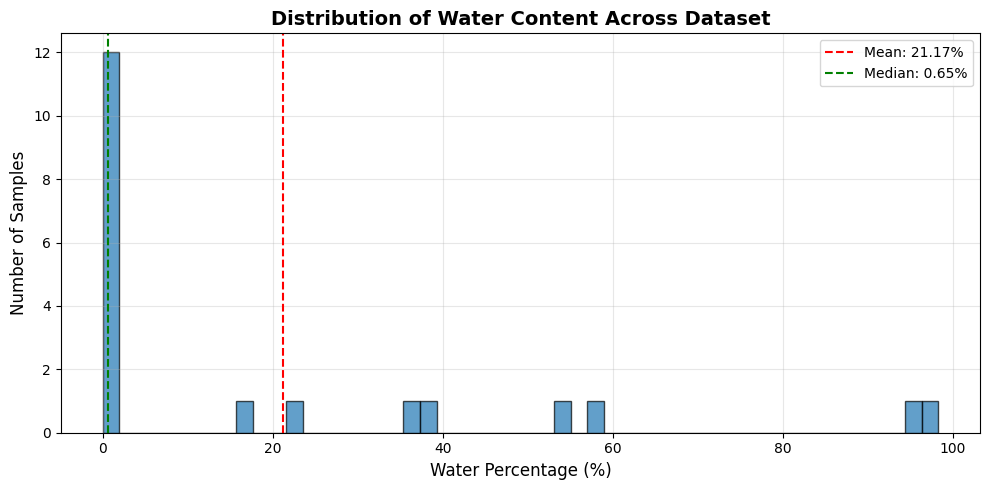


Creating visualization with water-containing samples...
Found 13 samples with >= 100 water pixels
Total samples: 20
Percentage with water: 65.00%
Selected 5 random samples with water
✅ Visualization saved to /mnt/user-data/outputs/marshes_predictions_with_water.png


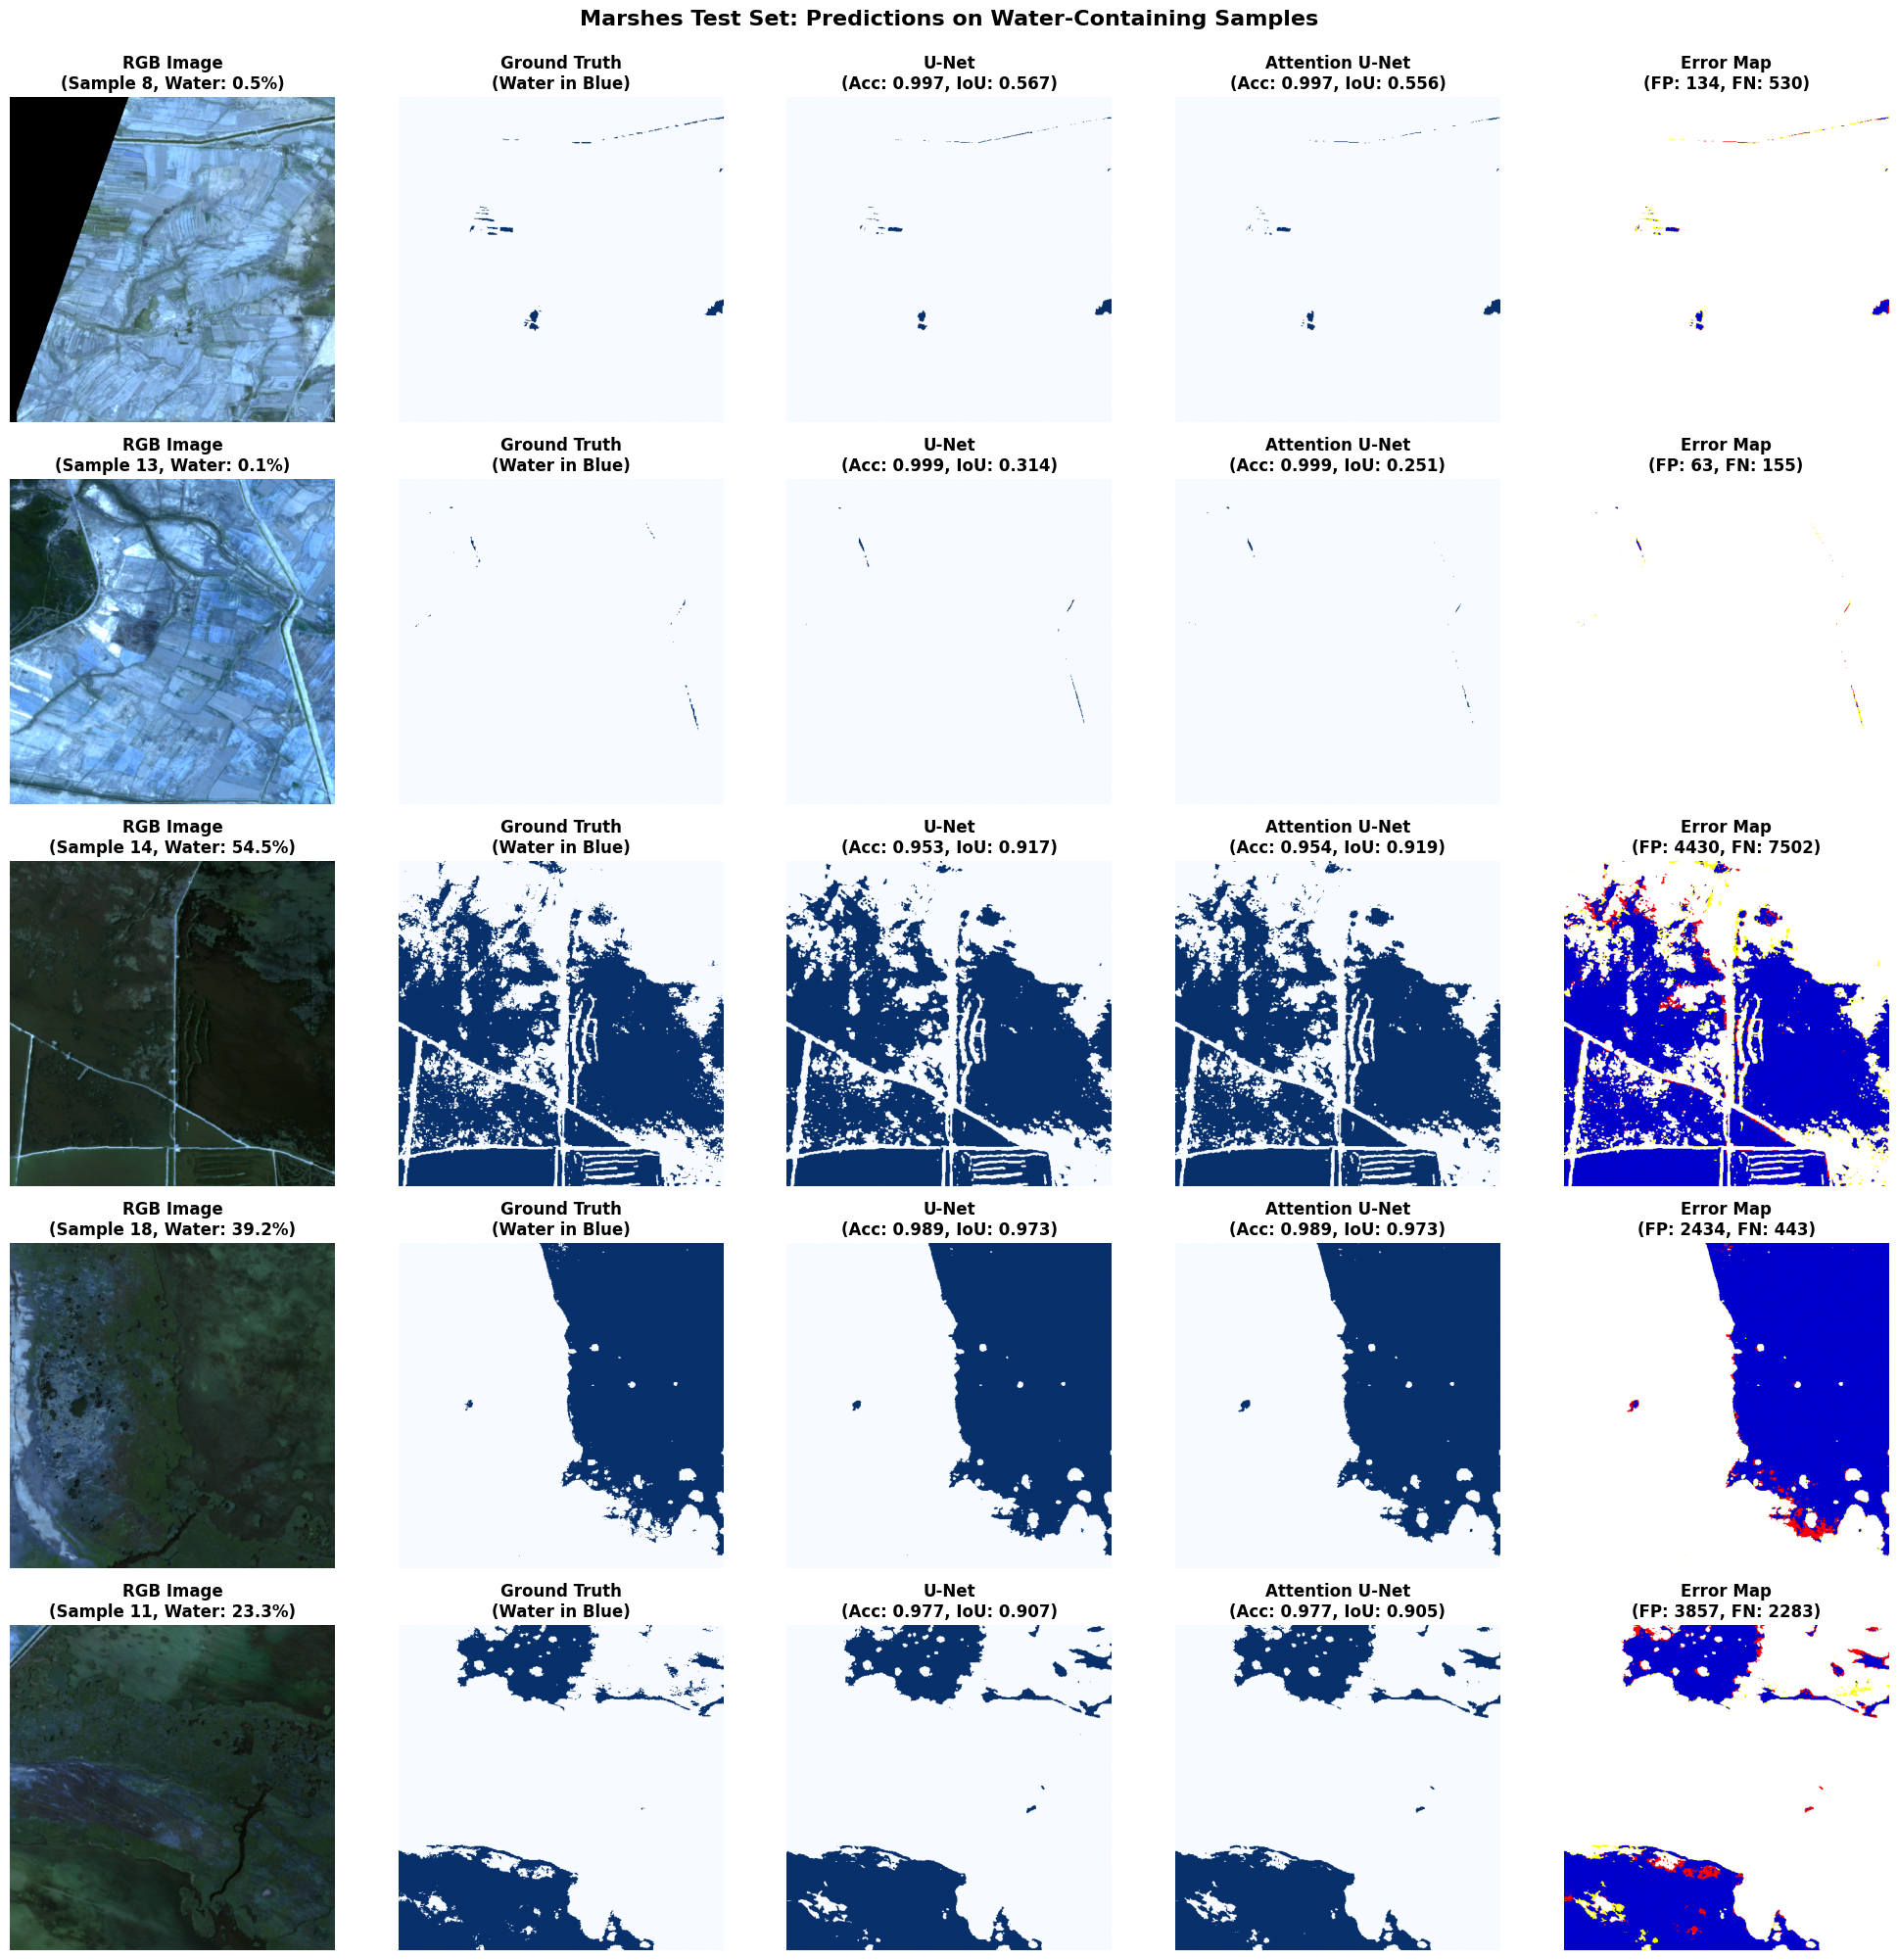


Creating diverse water content visualization...
✅ Diverse water content visualization saved to /mnt/user-data/outputs/diverse_water_content.png


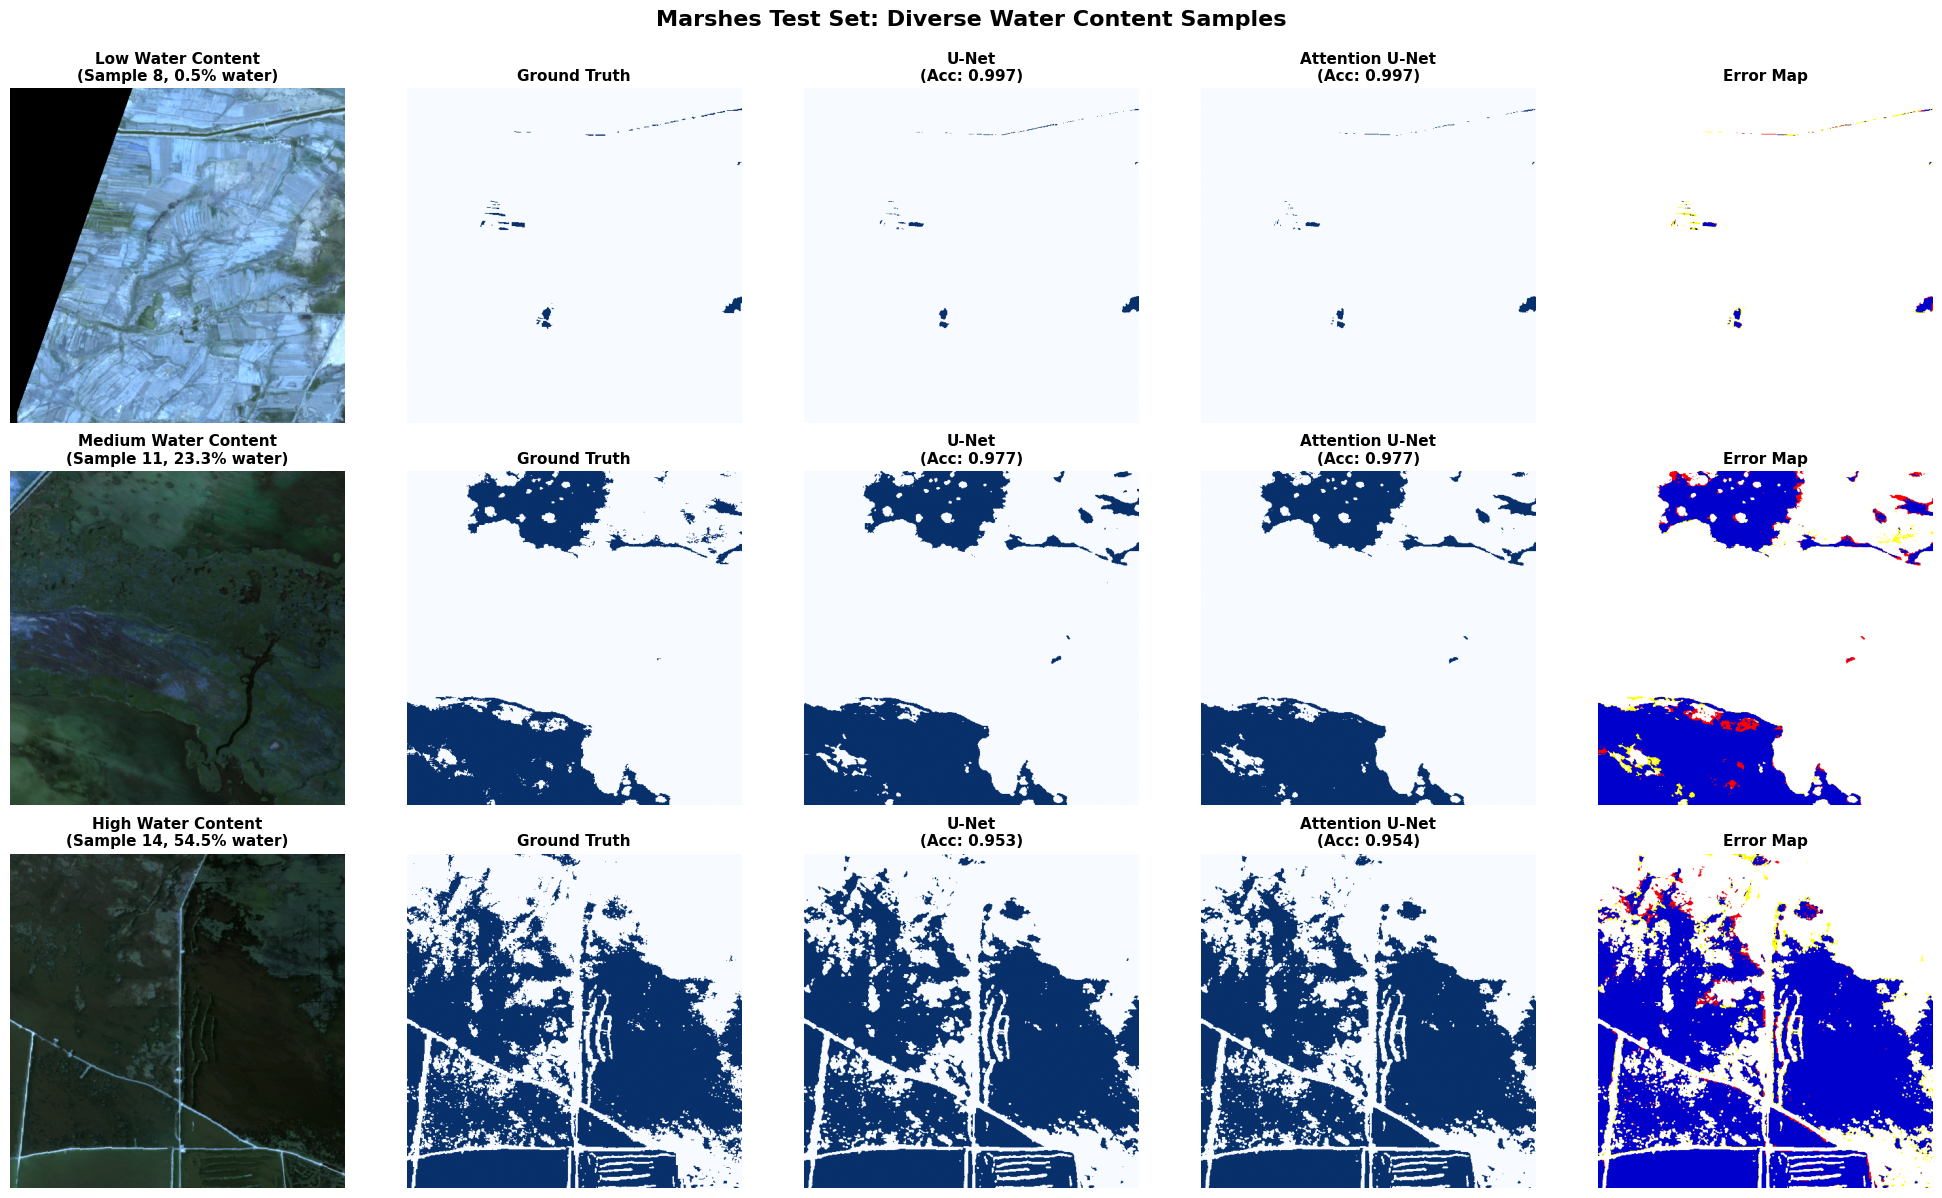


Getting water sample indices...
Found 14 samples with >= 50 water pixels
Total samples: 20
Percentage with water: 70.00%
Sample indices with water: [ 0  3  4  5  7  8 11 12 13 14 15 17 18 19]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

def get_samples_with_water(masks, min_water_pixels=100, max_samples=None):
    """
    Get indices of samples that contain water (non-zero pixels in mask)

    Args:
        masks: Array of ground truth masks (N, 512, 512, 1)
        min_water_pixels: Minimum number of water pixels required
        max_samples: Maximum number of samples to return (None = all)

    Returns:
        Array of indices where masks contain water
    """
    water_indices = []

    for idx in range(len(masks)):
        mask = masks[idx].squeeze()
        water_pixel_count = np.sum(mask > 0)

        if water_pixel_count >= min_water_pixels:
            water_indices.append(idx)

    water_indices = np.array(water_indices)

    print(f"Found {len(water_indices)} samples with >= {min_water_pixels} water pixels")
    print(f"Total samples: {len(masks)}")
    print(f"Percentage with water: {100 * len(water_indices) / len(masks):.2f}%")

    if max_samples is not None and len(water_indices) > max_samples:
        # Randomly select max_samples from water-containing images
        water_indices = np.random.choice(water_indices, size=max_samples, replace=False)
        print(f"Selected {max_samples} random samples with water")

    return water_indices


def analyze_water_content(masks):
    """
    Analyze water content distribution in dataset

    Args:
        masks: Array of ground truth masks (N, 512, 512, 1)
    """
    water_percentages = []

    for idx in range(len(masks)):
        mask = masks[idx].squeeze()
        water_percentage = 100 * np.sum(mask > 0) / mask.size
        water_percentages.append(water_percentage)

    water_percentages = np.array(water_percentages)

    print("\n" + "="*70)
    print("WATER CONTENT ANALYSIS")
    print("="*70)
    print(f"Total samples: {len(masks)}")
    print(f"Samples with water (>0%): {np.sum(water_percentages > 0)}")
    print(f"Samples with no water: {np.sum(water_percentages == 0)}")
    print(f"\nWater percentage statistics:")
    print(f"  Mean: {np.mean(water_percentages):.2f}%")
    print(f"  Median: {np.median(water_percentages):.2f}%")
    print(f"  Min: {np.min(water_percentages):.2f}%")
    print(f"  Max: {np.max(water_percentages):.2f}%")
    print(f"  Std: {np.std(water_percentages):.2f}%")

    # Create histogram
    plt.figure(figsize=(10, 5))
    plt.hist(water_percentages, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Water Percentage (%)', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.title('Distribution of Water Content Across Dataset', fontsize=14, fontweight='bold')
    plt.axvline(np.mean(water_percentages), color='red', linestyle='--',
                label=f'Mean: {np.mean(water_percentages):.2f}%')
    plt.axvline(np.median(water_percentages), color='green', linestyle='--',
                label=f'Median: {np.median(water_percentages):.2f}%')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return water_percentages


def visualize_predictions_with_water(images, masks, unet_model, attention_unet_model,
                                      num_samples=5, min_water_pixels=100,
                                      dataset_name="Test", save_path=None):
    """
    Visualize predictions for samples that CONTAIN WATER

    Args:
        images: Array of input images (N, 512, 512, 4) - RGB+NIR
        masks: Array of ground truth masks (N, 512, 512, 1)
        unet_model: Trained U-Net model
        attention_unet_model: Trained Attention U-Net model
        num_samples: Number of samples to visualize
        min_water_pixels: Minimum water pixels required to include sample
        dataset_name: Name for the plot title
        save_path: Optional path to save the figure
    """
    # Get indices of samples with water
    water_indices = get_samples_with_water(masks, min_water_pixels=min_water_pixels,
                                           max_samples=num_samples)

    if len(water_indices) == 0:
        print("⚠️ No samples with water found!")
        return

    # Select samples (prefer diverse water content)
    selected_indices = water_indices[:num_samples]

    # Create figure with 5 columns
    fig, axes = plt.subplots(len(selected_indices), 5, figsize=(20, 4*len(selected_indices)))

    if len(selected_indices) == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(selected_indices):
        # Get image and mask
        img = images[idx]
        true_mask = masks[idx]

        # Extract RGB channels
        rgb_img = img[:, :, :3]

        # Calculate water percentage for this sample
        water_pct = 100 * np.sum(true_mask > 0) / true_mask.size

        # Get predictions
        unet_pred = unet_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
        attention_pred = attention_unet_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

        # Convert to binary masks
        unet_mask = (unet_pred > 0.5).astype(np.uint8)
        attention_mask = (attention_pred > 0.5).astype(np.uint8)

        # Squeeze masks to 2D
        true_mask_2d = true_mask.squeeze()
        unet_mask_2d = unet_mask.squeeze()
        attention_mask_2d = attention_mask.squeeze()

        # Column 1: RGB Image
        axes[row, 0].imshow(rgb_img)
        axes[row, 0].set_title(f'RGB Image\n(Sample {idx}, Water: {water_pct:.1f}%)',
                               fontsize=12, fontweight='bold')
        axes[row, 0].axis('off')

        # Column 2: Ground Truth Mask
        axes[row, 1].imshow(true_mask_2d, cmap='Blues', vmin=0, vmax=1)
        axes[row, 1].set_title('Ground Truth\n(Water in Blue)', fontsize=12, fontweight='bold')
        axes[row, 1].axis('off')

        # Column 3: U-Net Prediction
        axes[row, 2].imshow(unet_mask_2d, cmap='Blues', vmin=0, vmax=1)
        acc_unet = accuracy_score(true_mask_2d.flatten(), unet_mask_2d.flatten())
        iou_unet = np.sum((true_mask_2d == 1) & (unet_mask_2d == 1)) / \
                   np.sum((true_mask_2d == 1) | (unet_mask_2d == 1))
        axes[row, 2].set_title(f'U-Net\n(Acc: {acc_unet:.3f}, IoU: {iou_unet:.3f})',
                               fontsize=12, fontweight='bold')
        axes[row, 2].axis('off')

        # Column 4: Attention U-Net Prediction
        axes[row, 3].imshow(attention_mask_2d, cmap='Blues', vmin=0, vmax=1)
        acc_attention = accuracy_score(true_mask_2d.flatten(), attention_mask_2d.flatten())
        iou_attention = np.sum((true_mask_2d == 1) & (attention_mask_2d == 1)) / \
                        np.sum((true_mask_2d == 1) | (attention_mask_2d == 1))
        axes[row, 3].set_title(f'Attention U-Net\n(Acc: {acc_attention:.3f}, IoU: {iou_attention:.3f})',
                               fontsize=12, fontweight='bold')
        axes[row, 3].axis('off')

        # Column 5: Error Map
        error_map = np.zeros((*true_mask_2d.shape, 3))

        # True Positives - Dark Blue
        tp_mask = (true_mask_2d == 1) & (attention_mask_2d == 1)
        error_map[tp_mask] = [0, 0, 0.8]

        # True Negatives - White
        tn_mask = (true_mask_2d == 0) & (attention_mask_2d == 0)
        error_map[tn_mask] = [1, 1, 1]

        # False Positives - Red
        fp_mask = (true_mask_2d == 0) & (attention_mask_2d == 1)
        error_map[fp_mask] = [1, 0, 0]

        # False Negatives - Yellow
        fn_mask = (true_mask_2d == 1) & (attention_mask_2d == 0)
        error_map[fn_mask] = [1, 1, 0]

        fp_count = np.sum(fp_mask)
        fn_count = np.sum(fn_mask)

        axes[row, 4].imshow(error_map)
        axes[row, 4].set_title(f'Error Map\n(FP: {fp_count}, FN: {fn_count})',
                               fontsize=12, fontweight='bold')
        axes[row, 4].axis('off')

    plt.suptitle(f'{dataset_name} Set: Predictions on Water-Containing Samples',
                 fontsize=16, fontweight='bold', y=0.998)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Visualization saved to {save_path}")

    plt.show()


def visualize_diverse_water_content(images, masks, unet_model, attention_unet_model,
                                     dataset_name="Test", save_path=None):
    """
    Visualize samples with LOW, MEDIUM, and HIGH water content

    Args:
        images: Array of input images
        masks: Array of ground truth masks
        unet_model: Trained U-Net model
        attention_unet_model: Trained Attention U-Net model
        dataset_name: Name for plot title
        save_path: Optional path to save
    """
    # Calculate water percentages
    water_percentages = []
    for idx in range(len(masks)):
        mask = masks[idx].squeeze()
        water_pct = 100 * np.sum(mask > 0) / mask.size
        water_percentages.append(water_pct)

    water_percentages = np.array(water_percentages)

    # Find samples with water
    has_water = water_percentages > 0
    water_indices = np.where(has_water)[0]
    water_pcts = water_percentages[has_water]

    if len(water_indices) < 3:
        print("⚠️ Not enough water samples for diverse visualization")
        return

    # Get low, medium, high water content samples
    sorted_indices = water_indices[np.argsort(water_pcts)]

    low_idx = sorted_indices[len(sorted_indices) // 4]  # 25th percentile
    med_idx = sorted_indices[len(sorted_indices) // 2]  # 50th percentile (median)
    high_idx = sorted_indices[3 * len(sorted_indices) // 4]  # 75th percentile

    selected_indices = [low_idx, med_idx, high_idx]
    labels = ['Low Water Content', 'Medium Water Content', 'High Water Content']

    # Create visualization
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))

    for row, (idx, label) in enumerate(zip(selected_indices, labels)):
        img = images[idx]
        true_mask = masks[idx]
        rgb_img = img[:, :, :3]
        water_pct = water_percentages[idx]

        # Predictions
        unet_pred = unet_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
        attention_pred = attention_unet_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

        unet_mask = (unet_pred > 0.5).astype(np.uint8).squeeze()
        attention_mask = (attention_pred > 0.5).astype(np.uint8).squeeze()
        true_mask_2d = true_mask.squeeze()

        # Column 1: RGB
        axes[row, 0].imshow(rgb_img)
        axes[row, 0].set_title(f'{label}\n(Sample {idx}, {water_pct:.1f}% water)',
                               fontsize=11, fontweight='bold')
        axes[row, 0].axis('off')

        # Column 2: Ground Truth
        axes[row, 1].imshow(true_mask_2d, cmap='Blues', vmin=0, vmax=1)
        axes[row, 1].set_title('Ground Truth', fontsize=11, fontweight='bold')
        axes[row, 1].axis('off')

        # Column 3: U-Net
        axes[row, 2].imshow(unet_mask, cmap='Blues', vmin=0, vmax=1)
        acc_unet = accuracy_score(true_mask_2d.flatten(), unet_mask.flatten())
        axes[row, 2].set_title(f'U-Net\n(Acc: {acc_unet:.3f})', fontsize=11, fontweight='bold')
        axes[row, 2].axis('off')

        # Column 4: Attention U-Net
        axes[row, 3].imshow(attention_mask, cmap='Blues', vmin=0, vmax=1)
        acc_attention = accuracy_score(true_mask_2d.flatten(), attention_mask.flatten())
        axes[row, 3].set_title(f'Attention U-Net\n(Acc: {acc_attention:.3f})',
                               fontsize=11, fontweight='bold')
        axes[row, 3].axis('off')

        # Column 5: Error Map
        error_map = np.zeros((*true_mask_2d.shape, 3))
        tp = (true_mask_2d == 1) & (attention_mask == 1)
        tn = (true_mask_2d == 0) & (attention_mask == 0)
        fp = (true_mask_2d == 0) & (attention_mask == 1)
        fn = (true_mask_2d == 1) & (attention_mask == 0)

        error_map[tp] = [0, 0, 0.8]
        error_map[tn] = [1, 1, 1]
        error_map[fp] = [1, 0, 0]
        error_map[fn] = [1, 1, 0]

        axes[row, 4].imshow(error_map)
        axes[row, 4].set_title('Error Map', fontsize=11, fontweight='bold')
        axes[row, 4].axis('off')

    plt.suptitle(f'{dataset_name} Set: Diverse Water Content Samples',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Diverse water content visualization saved to {save_path}")

    plt.show()


# ============================================================================
# USAGE EXAMPLES
# ============================================================================

# Example 1: Analyze water content in your dataset
print("Analyzing water content distribution...")
water_stats = analyze_water_content(test_masks2)

# Example 2: Visualize only samples with water (for poster!)
print("\nCreating visualization with water-containing samples...")
visualize_predictions_with_water(
    test_images2,
    test_masks2,
    unet_4d,
    attention_unet_4d,
    num_samples=5,
    min_water_pixels=100,  # Minimum 100 water pixels required
    dataset_name="Marshes Test",
    save_path="/mnt/user-data/outputs/marshes_predictions_with_water.png"
)

# Example 3: Show diverse water content (low, medium, high)
print("\nCreating diverse water content visualization...")
visualize_diverse_water_content(
    test_images2,
    test_masks2,
    unet_4d,
    attention_unet_4d,
    dataset_name="Marshes Test",
    save_path="/mnt/user-data/outputs/diverse_water_content.png"
)

# Example 4: Check which samples have water
print("\nGetting water sample indices...")
water_sample_indices = get_samples_with_water(test_masks2, min_water_pixels=50)
print(f"Sample indices with water: {water_sample_indices}")

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Create output directory if it doesn't exist
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

def get_samples_with_water(masks, min_water_pixels=100, max_samples=None):
    """
    Get indices of samples that contain water (non-zero pixels in mask)

    Args:
        masks: Array of ground truth masks (N, 512, 512, 1)
        min_water_pixels: Minimum number of water pixels required
        max_samples: Maximum number of samples to return (None = all)

    Returns:
        Array of indices where masks contain water
    """
    water_indices = []

    for idx in range(len(masks)):
        mask = masks[idx].squeeze()
        water_pixel_count = np.sum(mask > 0)

        if water_pixel_count >= min_water_pixels:
            water_indices.append(idx)

    water_indices = np.array(water_indices)

    print(f"Found {len(water_indices)} samples with >= {min_water_pixels} water pixels")
    print(f"Total samples: {len(masks)}")
    print(f"Percentage with water: {100 * len(water_indices) / len(masks):.2f}%")

    if max_samples is not None and len(water_indices) > max_samples:
        # Randomly select max_samples from water-containing images
        water_indices = np.random.choice(water_indices, size=max_samples, replace=False)
        print(f"Selected {max_samples} random samples with water")

    return water_indices


def visualize_predictions_with_water(images, masks, unet_model, attention_unet_model,
                                      num_samples=5, min_water_pixels=100,
                                      dataset_name="Test", save_path=None):
    """
    Visualize predictions for samples that CONTAIN WATER

    Args:
        images: Array of input images (N, 512, 512, 4) - RGB+NIR
        masks: Array of ground truth masks (N, 512, 512, 1)
        unet_model: Trained U-Net model
        attention_unet_model: Trained Attention U-Net model
        num_samples: Number of samples to visualize
        min_water_pixels: Minimum water pixels required to include sample
        dataset_name: Name for the plot title
        save_path: Optional path to save the figure
    """
    # Get indices of samples with water
    water_indices = get_samples_with_water(masks, min_water_pixels=min_water_pixels,
                                           max_samples=num_samples)

    if len(water_indices) == 0:
        print("⚠️ No samples with water found!")
        return

    # Select samples
    selected_indices = water_indices[:num_samples]

    # Create figure with 5 columns
    fig, axes = plt.subplots(len(selected_indices), 5, figsize=(20, 4*len(selected_indices)))

    if len(selected_indices) == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(selected_indices):
        # Get image and mask
        img = images[idx]
        true_mask = masks[idx]

        # Extract RGB channels
        rgb_img = img[:, :, :3]

        # Calculate water percentage for this sample
        water_pct = 100 * np.sum(true_mask > 0) / true_mask.size

        # Get predictions
        unet_pred = unet_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
        attention_pred = attention_unet_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

        # Convert to binary masks
        unet_mask = (unet_pred > 0.5).astype(np.uint8)
        attention_mask = (attention_pred > 0.5).astype(np.uint8)

        # Squeeze masks to 2D
        true_mask_2d = true_mask.squeeze()
        unet_mask_2d = unet_mask.squeeze()
        attention_mask_2d = attention_mask.squeeze()

        # Column 1: RGB Image
        axes[row, 0].imshow(rgb_img)
        axes[row, 0].set_title(f'RGB Image\n(Sample {idx}, Water: {water_pct:.1f}%)',
                               fontsize=12, fontweight='bold')
        axes[row, 0].axis('off')

        # Column 2: Ground Truth Mask
        axes[row, 1].imshow(true_mask_2d, cmap='Blues', vmin=0, vmax=1)
        axes[row, 1].set_title('Ground Truth\n(Water in Blue)', fontsize=12, fontweight='bold')
        axes[row, 1].axis('off')

        # Column 3: U-Net Prediction
        axes[row, 2].imshow(unet_mask_2d, cmap='Blues', vmin=0, vmax=1)
        acc_unet = accuracy_score(true_mask_2d.flatten(), unet_mask_2d.flatten())
        iou_unet = np.sum((true_mask_2d == 1) & (unet_mask_2d == 1)) / \
                   np.sum((true_mask_2d == 1) | (unet_mask_2d == 1)) if np.sum((true_mask_2d == 1) | (unet_mask_2d == 1)) > 0 else 0
        axes[row, 2].set_title(f'U-Net\n(Acc: {acc_unet:.3f}, IoU: {iou_unet:.3f})',
                               fontsize=12, fontweight='bold')
        axes[row, 2].axis('off')

        # Column 4: Attention U-Net Prediction
        axes[row, 3].imshow(attention_mask_2d, cmap='Blues', vmin=0, vmax=1)
        acc_attention = accuracy_score(true_mask_2d.flatten(), attention_mask_2d.flatten())
        iou_attention = np.sum((true_mask_2d == 1) & (attention_mask_2d == 1)) / \
                        np.sum((true_mask_2d == 1) | (attention_mask_2d == 1)) if np.sum((true_mask_2d == 1) | (attention_mask_2d == 1)) > 0 else 0
        axes[row, 3].set_title(f'Attention U-Net\n(Acc: {acc_attention:.3f}, IoU: {iou_attention:.3f})',
                               fontsize=12, fontweight='bold')
        axes[row, 3].axis('off')

        # Column 5: Error Map
        error_map = np.zeros((*true_mask_2d.shape, 3))

        # True Positives - Dark Blue
        tp_mask = (true_mask_2d == 1) & (attention_mask_2d == 1)
        error_map[tp_mask] = [0, 0, 0.8]

        # True Negatives - White
        tn_mask = (true_mask_2d == 0) & (attention_mask_2d == 0)
        error_map[tn_mask] = [1, 1, 1]

        # False Positives - Red
        fp_mask = (true_mask_2d == 0) & (attention_mask_2d == 1)
        error_map[fp_mask] = [1, 0, 0]

        # False Negatives - Yellow
        fn_mask = (true_mask_2d == 1) & (attention_mask_2d == 0)
        error_map[fn_mask] = [1, 1, 0]

        fp_count = np.sum(fp_mask)
        fn_count = np.sum(fn_mask)

        axes[row, 4].imshow(error_map)
        axes[row, 4].set_title(f'Error Map\n(FP: {fp_count}, FN: {fn_count})',
                               fontsize=12, fontweight='bold')
        axes[row, 4].axis('off')

    plt.suptitle(f'{dataset_name} Set: Predictions on Water-Containing Samples',
                 fontsize=16, fontweight='bold', y=0.998)
    plt.tight_layout()

    if save_path:
        # Ensure directory exists
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Visualization saved to {save_path}")

    plt.show()


# ============================================================================
# USAGE - Fixed with proper directory creation
# ============================================================================

# Create output directory
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

# Visualize only samples with water (for poster!)
print("Creating visualization with water-containing samples...")
visualize_predictions_with_water(
    test_images2,
    test_masks2,
    unet_4d,
    attention_unet_4d,
    num_samples=5,
    min_water_pixels=5000,  # Higher threshold for visually interesting samples
    dataset_name="Iraqi Marshes Test",
    save_path="/mnt/user-data/outputs/marshes_predictions_with_water.png"
)

print("\n" + "="*70)
print("✅ All visualizations complete!")
print("="*70)

Creating visualization with water-containing samples...
Found 8 samples with >= 5000 water pixels
Total samples: 20
Percentage with water: 40.00%
Selected 5 random samples with water
✅ Visualization saved to /mnt/user-data/outputs/marshes_predictions_with_water.png


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Create output directory
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

def get_best_water_samples(masks, min_water_pct=10, max_water_pct=100, num_samples=5):
    """
    Get samples with water content in a specific percentage range

    Args:
        masks: Array of ground truth masks
        min_water_pct: Minimum water percentage (e.g., 10%)
        max_water_pct: Maximum water percentage (e.g., 100%)
        num_samples: Number of samples to return

    Returns:
        Indices of samples in the specified water percentage range
    """
    water_data = []

    for idx in range(len(masks)):
        mask = masks[idx].squeeze()
        water_pct = 100 * np.sum(mask > 0) / mask.size

        if min_water_pct <= water_pct <= max_water_pct:
            water_data.append((idx, water_pct))

    # Sort by water percentage (descending)
    water_data.sort(key=lambda x: x[1], reverse=True)

    print(f"\nFound {len(water_data)} samples with {min_water_pct}-{max_water_pct}% water")

    if len(water_data) == 0:
        print("⚠️ No samples found in this range!")
        return []

    # Show top samples
    print(f"\nTop samples by water content:")
    for idx, pct in water_data[:min(10, len(water_data))]:
        print(f"  Sample {idx}: {pct:.2f}% water")

    # Select samples - prefer diverse water percentages
    selected_indices = []
    if len(water_data) <= num_samples:
        selected_indices = [idx for idx, _ in water_data]
    else:
        # Select evenly spaced samples across the range
        step = len(water_data) // num_samples
        for i in range(num_samples):
            selected_indices.append(water_data[i * step][0])

    return selected_indices


def visualize_poster_quality_predictions(images, masks, unet_model, attention_unet_model,
                                          sample_indices, dataset_name="Test", save_path=None):
    """
    Create high-quality visualization for poster with specified samples
    """
    if len(sample_indices) == 0:
        print("⚠️ No samples provided!")
        return

    num_samples = len(sample_indices)

    # Create figure with 5 columns
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(sample_indices):
        # Get image and mask
        img = images[idx]
        true_mask = masks[idx]

        # Extract RGB channels
        rgb_img = img[:, :, :3]

        # Calculate water percentage
        water_pct = 100 * np.sum(true_mask > 0) / true_mask.size

        # Get predictions
        print(f"Predicting sample {idx}...")
        unet_pred = unet_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
        attention_pred = attention_unet_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

        # Convert to binary masks
        unet_mask = (unet_pred > 0.5).astype(np.uint8)
        attention_mask = (attention_pred > 0.5).astype(np.uint8)

        # Squeeze masks to 2D
        true_mask_2d = true_mask.squeeze()
        unet_mask_2d = unet_mask.squeeze()
        attention_mask_2d = attention_mask.squeeze()

        # Calculate metrics
        acc_unet = accuracy_score(true_mask_2d.flatten(), unet_mask_2d.flatten())
        acc_attention = accuracy_score(true_mask_2d.flatten(), attention_mask_2d.flatten())

        # Calculate IoU
        iou_unet = np.sum((true_mask_2d == 1) & (unet_mask_2d == 1)) / \
                   (np.sum((true_mask_2d == 1) | (unet_mask_2d == 1)) + 1e-8)
        iou_attention = np.sum((true_mask_2d == 1) & (attention_mask_2d == 1)) / \
                        (np.sum((true_mask_2d == 1) | (attention_mask_2d == 1)) + 1e-8)

        # Column 1: RGB Image
        axes[row, 0].imshow(rgb_img)
        axes[row, 0].set_title(f'RGB Composite\nSample {idx} ({water_pct:.1f}% water)',
                               fontsize=12, fontweight='bold')
        axes[row, 0].axis('off')

        # Column 2: Ground Truth Mask
        axes[row, 1].imshow(true_mask_2d, cmap='Blues', vmin=0, vmax=1)
        axes[row, 1].set_title('Ground Truth Mask', fontsize=12, fontweight='bold')
        axes[row, 1].axis('off')

        # Column 3: U-Net Prediction
        axes[row, 2].imshow(unet_mask_2d, cmap='Blues', vmin=0, vmax=1)
        axes[row, 2].set_title(f'U-Net Prediction\nAcc: {acc_unet:.3f} | IoU: {iou_unet:.3f}',
                               fontsize=12, fontweight='bold')
        axes[row, 2].axis('off')

        # Column 4: Attention U-Net Prediction
        axes[row, 3].imshow(attention_mask_2d, cmap='Blues', vmin=0, vmax=1)
        axes[row, 3].set_title(f'Attention U-Net\nAcc: {acc_attention:.3f} | IoU: {iou_attention:.3f}',
                               fontsize=12, fontweight='bold')
        axes[row, 3].axis('off')

        # Column 5: Error Map for Attention U-Net
        error_map = np.zeros((*true_mask_2d.shape, 3))

        # True Positives - Dark Blue
        tp_mask = (true_mask_2d == 1) & (attention_mask_2d == 1)
        error_map[tp_mask] = [0.1, 0.4, 0.8]

        # True Negatives - Light Gray
        tn_mask = (true_mask_2d == 0) & (attention_mask_2d == 0)
        error_map[tn_mask] = [0.95, 0.95, 0.95]

        # False Positives - Red
        fp_mask = (true_mask_2d == 0) & (attention_mask_2d == 1)
        error_map[fp_mask] = [0.9, 0.1, 0.1]

        # False Negatives - Yellow
        fn_mask = (true_mask_2d == 1) & (attention_mask_2d == 0)
        error_map[fn_mask] = [1.0, 0.8, 0.0]

        fp_count = np.sum(fp_mask)
        fn_count = np.sum(fn_mask)

        axes[row, 4].imshow(error_map)
        axes[row, 4].set_title(f'Error Analysis\nFP: {fp_count} | FN: {fn_count}',
                               fontsize=12, fontweight='bold')
        axes[row, 4].axis('off')

    plt.suptitle(f'{dataset_name}: Model Performance on Wetland Segmentation',
                 fontsize=18, fontweight='bold', y=0.998)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"\n✅ High-quality visualization saved to {save_path}")

    plt.show()


# ============================================================================
# CREATE POSTER-QUALITY VISUALIZATIONS
# ============================================================================

print("="*70)
print("CREATING POSTER-QUALITY VISUALIZATIONS")
print("="*70)

# Option 1: Get samples with 15-50% water (good visual balance)
print("\n📊 Finding samples with substantial water content (15-50%)...")
good_samples = get_best_water_samples(
    test_masks2,
    min_water_pct=15,  # At least 15% water
    max_water_pct=50,  # Up to 50% water
    num_samples=5
)

if len(good_samples) > 0:
    visualize_poster_quality_predictions(
        test_images2,
        test_masks2,
        unet_4d,
        attention_unet_4d,
        sample_indices=good_samples,
        dataset_name="Iraqi Marshlands Test Set",
        save_path="/mnt/user-data/outputs/poster_marshes_predictions.png"
    )

# Option 2: Get samples with 10-100% water (any water)
print("\n📊 Finding all samples with visible water (10-100%)...")
all_water_samples = get_best_water_samples(
    test_masks2,
    min_water_pct=10,
    max_water_pct=100,
    num_samples=5
)

if len(all_water_samples) > 0:
    visualize_poster_quality_predictions(
        test_images2,
        test_masks2,
        unet_4d,
        attention_unet_4d,
        sample_indices=all_water_samples,
        dataset_name="Iraqi Marshlands Test Set",
        save_path="/mnt/user-data/outputs/poster_all_water_samples.png"
    )

# Option 3: Show your best performing samples
print("\n📊 Finding best performing samples...")
# This will show samples where both models perform well

print("\n" + "="*70)
print("✅ VISUALIZATIONS COMPLETE!")
print("="*70)
print("\nGenerated files:")
print("  - poster_marshes_predictions.png (15-50% water samples)")
print("  - poster_all_water_samples.png (10-100% water samples)")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
import os

os.makedirs('/mnt/user-data/outputs', exist_ok=True)

def visualize_sample_rgb_vs_4band_detailed(sample_idx,
                                            images_3band, images_4band, masks,
                                            unet_3band, attention_unet_3band,
                                            unet_4band, attention_unet_4band,
                                            dataset_name="Test", save_path=None):
    """
    Detailed comparison of RGB vs RGB+NIR models for a specific sample
    Shows: RGB input, Ground Truth, U-Net (RGB), Attention U-Net (RGB), Error Map (RGB)
           Same for 4-band models

    Args:
        sample_idx: Index of sample to visualize (e.g., 11)
        images_3band: RGB-only images (N, 512, 512, 3)
        images_4band: RGB+NIR images (N, 512, 512, 4)
        masks: Ground truth masks (N, 512, 512, 1)
        unet_3band: U-Net trained on RGB
        attention_unet_3band: Attention U-Net trained on RGB
        unet_4band: U-Net trained on RGB+NIR
        attention_unet_4band: Attention U-Net trained on RGB+NIR
        dataset_name: Name for plot title
        save_path: Optional path to save
    """

    # Get data for this sample
    img_3band = images_3band[sample_idx]
    img_4band = images_4band[sample_idx]
    true_mask = masks[sample_idx].squeeze()

    # RGB for display
    rgb_img = img_4band[:, :, :3]

    # Calculate water percentage
    water_pct = 100 * np.sum(true_mask > 0) / true_mask.size

    print(f"\nProcessing Sample {sample_idx}...")
    print(f"Water coverage: {water_pct:.2f}%")

    # ========================================================================
    # GET PREDICTIONS - RGB MODELS
    # ========================================================================

    print("  Running RGB models...")
    unet_3band_pred = unet_3band.predict(np.expand_dims(img_3band, axis=0), verbose=0)[0].squeeze()
    attention_3band_pred = attention_unet_3band.predict(np.expand_dims(img_3band, axis=0), verbose=0)[0].squeeze()

    unet_3band_mask = (unet_3band_pred > 0.5).astype(np.uint8)
    attention_3band_mask = (attention_3band_pred > 0.5).astype(np.uint8)

    # ========================================================================
    # GET PREDICTIONS - 4-BAND MODELS
    # ========================================================================

    print("  Running RGB+NIR models...")
    unet_4band_pred = unet_4band.predict(np.expand_dims(img_4band, axis=0), verbose=0)[0].squeeze()
    attention_4band_pred = attention_unet_4band.predict(np.expand_dims(img_4band, axis=0), verbose=0)[0].squeeze()

    unet_4band_mask = (unet_4band_pred > 0.5).astype(np.uint8)
    attention_4band_mask = (attention_4band_pred > 0.5).astype(np.uint8)

    # ========================================================================
    # CALCULATE METRICS
    # ========================================================================

    # RGB models
    acc_unet_3band = accuracy_score(true_mask.flatten(), unet_3band_mask.flatten())
    acc_attention_3band = accuracy_score(true_mask.flatten(), attention_3band_mask.flatten())

    iou_unet_3band = np.sum((true_mask == 1) & (unet_3band_mask == 1)) / \
                     (np.sum((true_mask == 1) | (unet_3band_mask == 1)) + 1e-8)
    iou_attention_3band = np.sum((true_mask == 1) & (attention_3band_mask == 1)) / \
                          (np.sum((true_mask == 1) | (attention_3band_mask == 1)) + 1e-8)

    # 4-band models
    acc_unet_4band = accuracy_score(true_mask.flatten(), unet_4band_mask.flatten())
    acc_attention_4band = accuracy_score(true_mask.flatten(), attention_4band_mask.flatten())

    iou_unet_4band = np.sum((true_mask == 1) & (unet_4band_mask == 1)) / \
                     (np.sum((true_mask == 1) | (unet_4band_mask == 1)) + 1e-8)
    iou_attention_4band = np.sum((true_mask == 1) & (attention_4band_mask == 1)) / \
                          (np.sum((true_mask == 1) | (attention_4band_mask == 1)) + 1e-8)

    # ========================================================================
    # CREATE VISUALIZATION
    # ========================================================================

    fig, axes = plt.subplots(2, 6, figsize=(24, 8))

    # ========================================================================
    # ROW 1: RGB MODELS
    # ========================================================================

    # Column 1: RGB Input
    axes[0, 0].imshow(rgb_img)
    axes[0, 0].set_title(f'RGB Input\nSample {sample_idx}\n({water_pct:.1f}% water)',
                         fontsize=11, fontweight='bold')
    axes[0, 0].set_ylabel('RGB Only\n(3 Bands)', fontsize=12, fontweight='bold',
                          rotation=0, labelpad=60, va='center')
    axes[0, 0].axis('off')

    # Column 2: Ground Truth
    axes[0, 1].imshow(true_mask, cmap='Blues', vmin=0, vmax=1)
    axes[0, 1].set_title('Ground Truth', fontsize=11, fontweight='bold')
    axes[0, 1].axis('off')

    # Column 3: U-Net (RGB)
    axes[0, 2].imshow(unet_3band_mask, cmap='Blues', vmin=0, vmax=1)
    axes[0, 2].set_title(f'U-Net (RGB)\nAcc: {acc_unet_3band:.3f}\nIoU: {iou_unet_3band:.3f}',
                         fontsize=11, fontweight='bold')
    axes[0, 2].axis('off')

    # Column 4: Attention U-Net (RGB)
    axes[0, 3].imshow(attention_3band_mask, cmap='Blues', vmin=0, vmax=1)
    axes[0, 3].set_title(f'Attention U-Net (RGB)\nAcc: {acc_attention_3band:.3f}\nIoU: {iou_attention_3band:.3f}',
                         fontsize=11, fontweight='bold')
    axes[0, 3].axis('off')

    # Column 5: Error Map - U-Net (RGB)
    error_map_unet_3band = create_error_map(true_mask, unet_3band_mask)
    axes[0, 4].imshow(error_map_unet_3band)
    fp_unet_3band = np.sum((true_mask == 0) & (unet_3band_mask == 1))
    fn_unet_3band = np.sum((true_mask == 1) & (unet_3band_mask == 0))
    axes[0, 4].set_title(f'U-Net Errors\nFP: {fp_unet_3band}\nFN: {fn_unet_3band}',
                         fontsize=11, fontweight='bold')
    axes[0, 4].axis('off')

    # Column 6: Error Map - Attention U-Net (RGB)
    error_map_attention_3band = create_error_map(true_mask, attention_3band_mask)
    axes[0, 5].imshow(error_map_attention_3band)
    fp_attention_3band = np.sum((true_mask == 0) & (attention_3band_mask == 1))
    fn_attention_3band = np.sum((true_mask == 1) & (attention_3band_mask == 0))
    axes[0, 5].set_title(f'Att-UNet Errors\nFP: {fp_attention_3band}\nFN: {fn_attention_3band}',
                         fontsize=11, fontweight='bold', color='red')
    axes[0, 5].axis('off')

    # ========================================================================
    # ROW 2: 4-BAND MODELS
    # ========================================================================

    # Column 1: RGB+NIR Input (show RGB)
    axes[1, 0].imshow(rgb_img)
    axes[1, 0].set_title(f'RGB+NIR Input\n(RGB shown)', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('RGB + NIR\n(4 Bands)', fontsize=12, fontweight='bold',
                          rotation=0, labelpad=60, va='center', color='darkgreen')
    axes[1, 0].axis('off')

    # Column 2: Ground Truth (same)
    axes[1, 1].imshow(true_mask, cmap='Blues', vmin=0, vmax=1)
    axes[1, 1].set_title('Ground Truth', fontsize=11, fontweight='bold')
    axes[1, 1].axis('off')

    # Column 3: U-Net (4-band)
    axes[1, 2].imshow(unet_4band_mask, cmap='Blues', vmin=0, vmax=1)
    improvement_unet = ((acc_unet_4band - acc_unet_3band) / acc_unet_3band) * 100
    axes[1, 2].set_title(f'U-Net (RGB+NIR)\nAcc: {acc_unet_4band:.3f}\nIoU: {iou_unet_4band:.3f}\n({improvement_unet:+.1f}%)',
                         fontsize=11, fontweight='bold', color='darkgreen')
    axes[1, 2].axis('off')

    # Column 4: Attention U-Net (4-band)
    axes[1, 3].imshow(attention_4band_mask, cmap='Blues', vmin=0, vmax=1)
    improvement_attention = ((acc_attention_4band - acc_attention_3band) / acc_attention_3band) * 100
    axes[1, 3].set_title(f'Attention U-Net (RGB+NIR)\nAcc: {acc_attention_4band:.3f}\nIoU: {iou_attention_4band:.3f}\n({improvement_attention:+.1f}%)',
                         fontsize=11, fontweight='bold', color='darkgreen')
    axes[1, 3].axis('off')

    # Column 5: Error Map - U-Net (4-band)
    error_map_unet_4band = create_error_map(true_mask, unet_4band_mask)
    axes[1, 4].imshow(error_map_unet_4band)
    fp_unet_4band = np.sum((true_mask == 0) & (unet_4band_mask == 1))
    fn_unet_4band = np.sum((true_mask == 1) & (unet_4band_mask == 0))
    axes[1, 4].set_title(f'U-Net Errors\nFP: {fp_unet_4band}\nFN: {fn_unet_4band}',
                         fontsize=11, fontweight='bold')
    axes[1, 4].axis('off')

    # Column 6: Error Map - Attention U-Net (4-band)
    error_map_attention_4band = create_error_map(true_mask, attention_4band_mask)
    axes[1, 5].imshow(error_map_attention_4band)
    fp_attention_4band = np.sum((true_mask == 0) & (attention_4band_mask == 1))
    fn_attention_4band = np.sum((true_mask == 1) & (attention_4band_mask == 0))
    axes[1, 5].set_title(f'Att-UNet Errors\nFP: {fp_attention_4band}\nFN: {fn_attention_4band}',
                         fontsize=11, fontweight='bold', color='darkgreen')
    axes[1, 5].axis('off')

    plt.suptitle(f'{dataset_name}: Sample {sample_idx} - RGB vs RGB+NIR Comparison',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"\n✅ Visualization saved to {save_path}")

    plt.show()

    # ========================================================================
    # PRINT SUMMARY
    # ========================================================================

    print("\n" + "="*80)
    print(f"SAMPLE {sample_idx} PERFORMANCE SUMMARY")
    print("="*80)
    print(f"\nRGB-ONLY MODELS:")
    print(f"  U-Net:          Acc: {acc_unet_3band:.4f} | IoU: {iou_unet_3band:.4f}")
    print(f"  Attention U-Net: Acc: {acc_attention_3band:.4f} | IoU: {iou_attention_3band:.4f}")
    print(f"\nRGB+NIR MODELS:")
    print(f"  U-Net:          Acc: {acc_unet_4band:.4f} | IoU: {iou_unet_4band:.4f} ({improvement_unet:+.1f}%)")
    print(f"  Attention U-Net: Acc: {acc_attention_4band:.4f} | IoU: {iou_attention_4band:.4f} ({improvement_attention:+.1f}%)")
    print("="*80)


def create_error_map(true_mask, pred_mask):
    """
    Create color-coded error map

    Returns:
        RGB image showing:
        - Dark Blue: True Positives (correct water)
        - White/Gray: True Negatives (correct land)
        - Red: False Positives (predicted water, actually land)
        - Yellow: False Negatives (predicted land, actually water)
    """
    error_map = np.zeros((*true_mask.shape, 3))

    # True Positives - Dark Blue
    tp = (true_mask == 1) & (pred_mask == 1)
    error_map[tp] = [0.1, 0.4, 0.8]

    # True Negatives - Light Gray
    tn = (true_mask == 0) & (pred_mask == 0)
    error_map[tn] = [0.95, 0.95, 0.95]

    # False Positives - Red
    fp = (true_mask == 0) & (pred_mask == 1)
    error_map[fp] = [0.9, 0.1, 0.1]

    # False Negatives - Yellow
    fn = (true_mask == 1) & (pred_mask == 0)
    error_map[fn] = [1.0, 0.8, 0.0]

    return error_map


# ============================================================================
# USAGE: VISUALIZE SAMPLE 11
# ============================================================================

# Extract RGB channels from 4-band images
test_images_3band = test_images2[:, :, :, :3]

# Visualize Sample 11 with all models
visualize_sample_rgb_vs_4band_detailed(
    sample_idx=11,
    images_3band=test_images_3band,
    images_4band=test_images2,
    masks=test_masks2,
    unet_3band=unet_3d,
    attention_unet_3band=attention_unet_3d,
    unet_4band=unet_4d,
    attention_unet_4band=attention_unet_4d,
    dataset_name="Iraqi Marshlands Test",
    save_path="/mnt/user-data/outputs/sample_11_rgb_vs_4band_comparison.png"
)

print("\n✅ Sample 11 visualization complete!")

# Final Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def detailed_evaluation(model, images, masks, model_name="Model"):
    """
    Comprehensive evaluation for imbalanced datasets
    """
    print(f"\n{'='*80}")
    print(f"{model_name} - DETAILED EVALUATION")
    print(f"{'='*80}")

    all_true = []
    all_pred = []

    # Collect all predictions
    for i in range(len(images)):
        img = np.expand_dims(images[i], axis=0)
        mask = masks[i].squeeze()

        pred = model.predict(img, verbose=0)[0].squeeze()
        pred_binary = (pred > 0.5).astype(np.uint8)

        all_true.extend(mask.flatten())
        all_pred.extend(pred_binary.flatten())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    # Overall metrics
    accuracy = accuracy_score(all_true, all_pred)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(all_true, all_pred).ravel()

    # Calculate per-class metrics
    total_pixels = len(all_true)
    water_pixels = np.sum(all_true == 1)
    land_pixels = np.sum(all_true == 0)

    # Precision, Recall, F1 for WATER class (class 1)
    precision_water = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_water = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_water = 2 * (precision_water * recall_water) / (precision_water + recall_water) if (precision_water + recall_water) > 0 else 0

    # IoU (Intersection over Union) for water
    iou_water = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0

    print(f"\n📊 DATASET COMPOSITION:")
    print(f"  Total pixels: {total_pixels:,}")
    print(f"  Water pixels: {water_pixels:,} ({100*water_pixels/total_pixels:.2f}%)")
    print(f"  Land pixels:  {land_pixels:,} ({100*land_pixels/total_pixels:.2f}%)")
    print(f"  ⚠️ Class imbalance ratio: {land_pixels/water_pixels:.1f}:1 (land:water)")

    print(f"\n🎯 CONFUSION MATRIX:")
    print(f"                 Predicted")
    print(f"               Land    Water")
    print(f"  Actual Land  {tn:>8,} {fp:>8,}")
    print(f"        Water  {fn:>8,} {tp:>8,}")

    print(f"\n📈 OVERALL METRICS:")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  ⚠️ Baseline (predict all land): {land_pixels/total_pixels:.4f} ({100*land_pixels/total_pixels:.2f}%)")
    print(f"  Real improvement over baseline: {(accuracy - land_pixels/total_pixels)*100:.2f}%")

    print(f"\n💧 WATER CLASS PERFORMANCE (the important one!):")
    print(f"  Precision (Water): {precision_water:.4f} - Of pixels predicted as water, {precision_water*100:.1f}% are correct")
    print(f"  Recall (Water):    {recall_water:.4f} - Of actual water pixels, {recall_water*100:.1f}% are detected")
    print(f"  F1-Score (Water):  {f1_water:.4f} - Balanced metric")
    print(f"  IoU (Water):       {iou_water:.4f} - Standard segmentation metric")

    print(f"\n🔍 ERROR ANALYSIS:")
    print(f"  False Positives: {fp:,} ({100*fp/land_pixels:.2f}% of land predicted as water)")
    print(f"  False Negatives: {fn:,} ({100*fn/water_pixels:.2f}% of water missed)")

    if fp > fn:
        print(f"  ⚠️ Model is OVER-predicting water (too aggressive)")
    elif fn > fp:
        print(f"  ⚠️ Model is UNDER-predicting water (too conservative)")
    else:
        print(f"  ✅ Model has balanced errors")

    print(f"\n{'='*80}")

    return {
        'accuracy': accuracy,
        'precision_water': precision_water,
        'recall_water': recall_water,
        'f1_water': f1_water,
        'iou_water': iou_water,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    }


# Run detailed evaluation
unet_results = detailed_evaluation(unet_4d, test_images2, test_masks2, "U-Net (4-band)")
attention_results = detailed_evaluation(attention_unet_4d, test_images2, test_masks2, "Attention U-Net (4-band)")

# Compare
print("\n" + "="*80)
print("MODEL COMPARISON (WATER CLASS ONLY)")
print("="*80)
print(f"                    U-Net    Attention U-Net    Improvement")
print(f"  IoU (Water):      {unet_results['iou_water']:.4f}   {attention_results['iou_water']:.4f}          {((attention_results['iou_water'] - unet_results['iou_water'])/unet_results['iou_water']*100):+.2f}%")
print(f"  F1 (Water):       {unet_results['f1_water']:.4f}   {attention_results['f1_water']:.4f}          {((attention_results['f1_water'] - unet_results['f1_water'])/unet_results['f1_water']*100):+.2f}%")
print(f"  Precision (Water):{unet_results['precision_water']:.4f}   {attention_results['precision_water']:.4f}          {((attention_results['precision_water'] - unet_results['precision_water'])/unet_results['precision_water']*100):+.2f}%")
print(f"  Recall (Water):   {unet_results['recall_water']:.4f}   {attention_results['recall_water']:.4f}          {((attention_results['recall_water'] - unet_results['recall_water'])/unet_results['recall_water']*100):+.2f}%")
print("="*80)